In [14]:
import numpy as np
import pandas as pd
import ast
import copy
import json
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestRegressor

import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

In [15]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def clear_gpu():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [2]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH =  "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [3]:
df_anomalies = pd.read_csv(LABELS)
df_anomalies.info()
df_anomalies.head(12)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

In [4]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Below, we just want to visualize an example of anomaly on channel 0 of a random telemetry.

Selected telemetry: E-8
Anomaly of telemetry: [[5400 6022]]


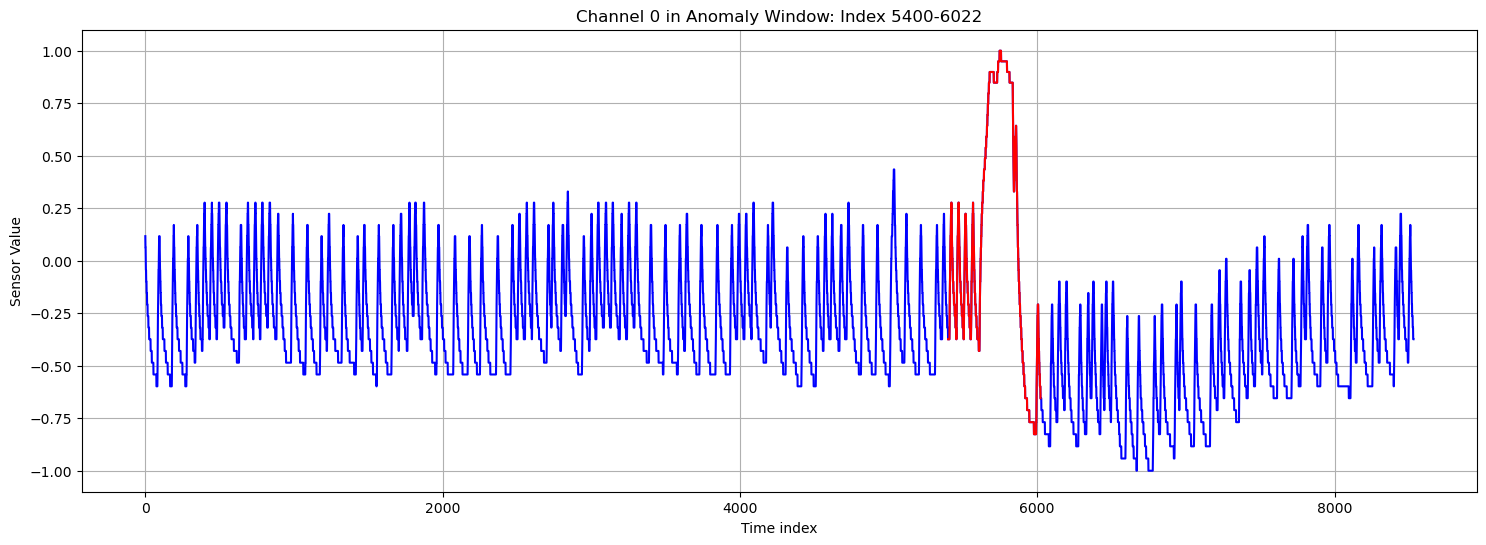

In [5]:
np.random.seed(10)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

The one reported, is one of anomalies classified as "contextual" as its behavior is anomalous if compared within the context, but not all anomalies are in this way in this dataset.

Selected telemetry: R-1
Anomaly of telemetry: [[4510 4590]]


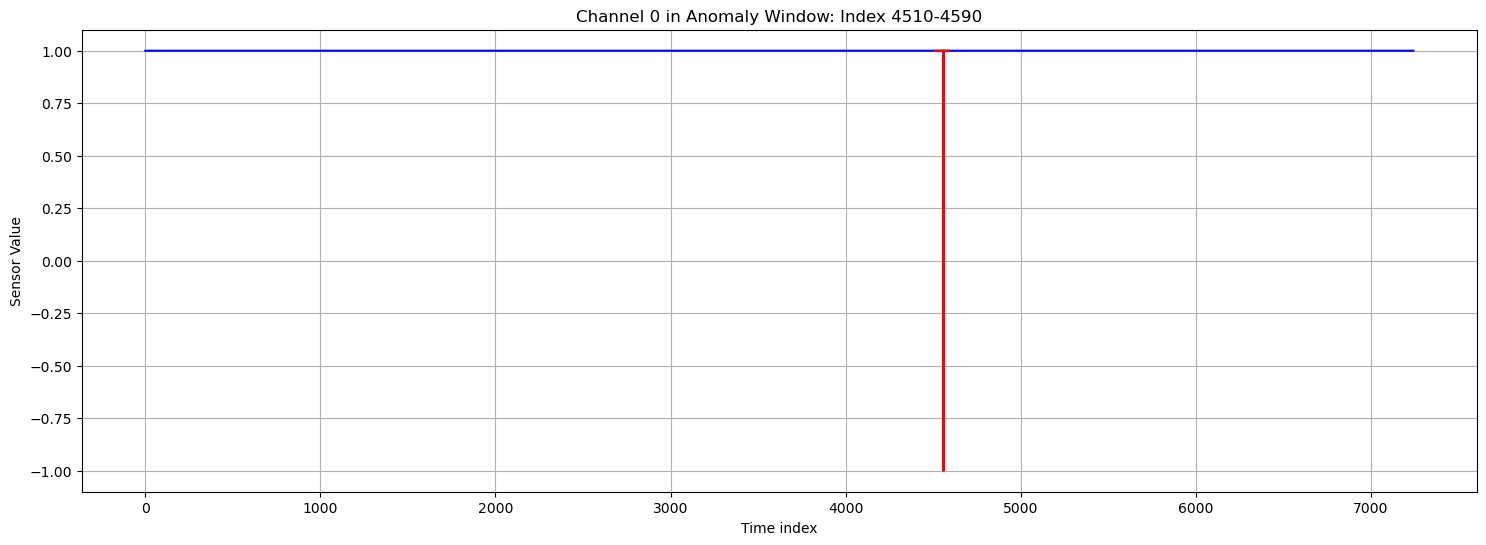

In [6]:
np.random.seed(4)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This one, is what is called "point" anomaly and it is easy to observe that the problem mainly relies on the value of the observed telemetry in a certain timestamp.

Our all around pipeline will be:\
START: test raw\
→ sliding windows\
→ prediction\
→ prediction errors\
→ smoothing errors\
→ thresholding\
→ anomaly buffer\
→ pruning / grouping sequences

## PREPROCESSING

The SMAP dataset is composed of multiple telemetry channels, each corresponding to a specific monitored signal from the Soil Moisture Active Passive satellite system. Each channel is stored as a multivariate time series with 25 features. The first feature represents the main telemetry signal to be modeled and forecasted, while the remaining 24 features represent auxiliary command-related variables. These command variables provide operational context: they describe external inputs or discrete system states that may influence the evolution of the main telemetry signal.

For this reason, the anomaly detection task is naturally framed as a forecasting problem. Given the recent history of the telemetry signal and the associated command variables, the model learns to predict the future behavior of the main signal. An anomaly is then identified when the observed signal deviates significantly from the expected behavior predicted under the current command context.

In this setting, a point anomaly can be interpreted as an isolated telemetry value that is physically unusual by itself, independently of the surrounding temporal context. For example, this may correspond to a sudden spike, drop, or value that lies far outside the usual operating range of the signal.

A contextual anomaly is instead a value that may not be abnormal in absolute terms, but becomes abnormal given the temporal and operational context. For example, a certain telemetry value may be acceptable under one command configuration, but unexpected when the command variables indicate a different operating condition. This interpretation is necessarily subjective, because the dataset does not provide a direct physical explanation for each labeled anomaly; the distinction is inferred from the structure of the data and from the forecasting-based anomaly detection setup.

In [7]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.std(X, axis=0)
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training files shows that all channels contain 25 features and no missing or infinite values. Feature values are mostly bounded in [-1, 1] or [0, 1], suggesting that the dataset has already been normalized before release. For this reason, no additional standard scaling is applied in the main pipeline.

A relevant aspect is the presence of several constant features within many channels. At first, dimensionality reduction techniques such as PCA were considered to remove redundant or non-informative components. However, the constant features are kept in the final preprocessing strategy because they may still carry useful operational information. Since some of these variables represent command signals, a flat signal can indicate the absence of a command and may therefore help the forecasting model distinguish normal operating conditions from anomalous behavior.

The training lengths are not uniform across channels, ranging from short sequences of a few hundred time steps to longer sequences close to 2880 time steps. This means that each channel should be treated independently, since the amount of available temporal context and the number of training windows differ substantially across telemetry streams.

### Windowing

The raw multivariate time series is converted into a supervised forecasting dataset using a sliding-window procedure. For each channel, fixed-length overlapping windows are extracted along the temporal axis.

For each starting index, the input sample `X` contains the past `window_size` observations of all available features. The corresponding target `y` is defined as the future values of the main telemetry signal only, i.e. feature `0`, over the next `n_predictions` time steps.

This transformation preserves the local temporal structure of the signal while making the data suitable for a forecasting model. The model receives the recent multivariate history of the system and learns to predict the future evolution of the main telemetry variable.

The use of overlapping windows increases the number of available samples, which is useful because the telemetry channels have different and sometimes limited lengths. The `stride` parameter controls how far the window is shifted at each step: with `stride = 1`, consecutive windows differ by one time step.

During training, the windows may be shuffled because the chronological order inside each individual window is preserved. During testing, the windows are kept in temporal order so that the sequence of predictions and anomaly scores can later be aligned with the original time series.

In [8]:
def make_forecasting_windows(X, window_size=250, n_predictions=10, stride=1):
    """
    Input:
        X[i : i + l_s]

    Target:
        X[i + l_s : i + l_s + n_predictions, 0]

    Note:
        The upper bound follows the original Telemanom implementation,
        i.e. without the final +1.
    """

    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size - n_predictions, stride):
        X_windows.append(X[i : i + window_size, :])
        y_windows.append(X[i + window_size : i + window_size + n_predictions, 0])

    return np.array(X_windows), np.array(y_windows)

### Test label construction

The binary test labels are built from the original labeled anomaly intervals. For each test channel, a raw binary vector is first created with the same length as the original test sequence: normal timesteps are marked as *0*, while timesteps belonging to an annotated anomaly interval are marked as *1*.

Since the forecasting dataset is built using input windows of length `window_size` and targets defined after each input window, the label vector must be aligned with the generated targets. The first target associated with the first input window starts at timestep `window_size` of the original test sequence.

For this reason, the raw label vector is shifted by `window_size` and truncated to the number of generated test windows:

$
y_{\text{test}} =
y_{\text{raw}}[\text{window\_size} :
\text{window\_size} + n_{\text{windows}}]
$

where

$
n_{\text{windows}} =
\text{len}(X_{\text{test}}) - \text{window\_size} - n_{\text{predictions}} + 1
$

This keeps the test labels aligned with the forecasted values, the prediction errors, and the final anomaly scores.

In [9]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x


def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y


def align_anomalies(labels_df, channel_id, X_test_raw, window_size=250, n_predictions=10):
    """
    Return labels in raw test coordinates, not shifted coordinates.
    The prediction indices are shifted later by l_s inside dynamic thresholding.
    """
    y_raw = np.zeros(len(X_test_raw), dtype=int)

    intervals = labels_df[labels_df["chan_id"] == channel_id]["anomaly_sequences"]

    for seq in intervals:
        for start, end in seq:
            y_raw[start:end + 1] = 1

    return y_raw

In [10]:
df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))

In [11]:
window_size = 250
n_predictions = 10
stride = 1

X_train_data = {}
X_test_data = {}
y_train_data = {}
y_test_data = {}
labels_data = {}

for ch in smap_channels_ids:
    path_train = TRAIN_PATH + '/' + ch + '.npy'
    path_test = TEST_PATH + '/' + ch + '.npy'

    x_train = np.load(path_train)
    x_test = np.load(path_test)

    X_train, y_train = make_forecasting_windows(
        x_train,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    X_test, y_test = make_forecasting_windows(
        x_test,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    labels = align_anomalies(
        labels_df=df_SMAP_anomalies,
        channel_id=ch,
        X_test_raw=x_test,
        window_size=window_size,
        n_predictions=n_predictions
    )

    X_train_data[ch] = X_train
    X_test_data[ch] = X_test
    y_train_data[ch] = y_train
    y_test_data[ch] = y_test
    labels_data[ch] = labels

Each telemetry channel has its own number of observations. After windowing, the input data for each channel have shape

$
[n_{\text{windows}},\; l_{\text{window}},\; n_{\text{features}}]
$

where $l_{\text{window}} = 250$ and $n_{\text{features}} = 25$.

The forecasting task is formulated as a multi-step-ahead prediction problem. For each channel, a sliding window of length 250 is extracted from the multivariate time series and used as input to the model. The target associated with each window is the future evolution of the main telemetry signal, i.e. feature 0, over the next $n_{\text{predictions}} = 10$ timesteps.

Hence, each sample has the form

$
X_i = [x_i, \ldots, x_{i+249}]
$

$
y_i = [x^{(0)}_{i+250}, \ldots, x^{(0)}_{i+259}]
$

where $x^{(0)}$ denotes the main telemetry feature.

Therefore, the model is not trained to reconstruct the input window, but to forecast the next 10 values of the main telemetry signal from the recent multivariate history and the corresponding command context. After prediction, the anomaly score is obtained by comparing the forecasted values with the actually observed values. Large prediction errors indicate that the observed behavior was not well explained by the recent temporal history and command configuration.

The same windowing procedure is applied independently to the training and test sequences of each channel. Test labels are then aligned with the generated forecasting windows so that anomaly annotations refer to the same temporal positions used for prediction-error evaluation.

In [12]:
ch = 'A-1'
print("X_train:", X_train_data[ch].shape)
print("y_train:", y_train_data[ch].shape)
print("X_test: ", X_test_data[ch].shape)
print("y_test: ", y_test_data[ch].shape)
print("labels: ", labels_data[ch].shape)

X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test:  (8380, 250, 25)
y_test:  (8380, 10)
labels:  (8640,)


## ANOMALY DETECTION STRATEGY

The anomaly detection strategy adopted in this project follows the forecasting-based approach proposed by Hundman et al. (2018) for spacecraft telemetry anomaly detection. Instead of detecting anomalies directly from the raw telemetry values, the model is first trained to predict the expected future behavior of the main telemetry signal. Anomalies are then identified from the forecasting error: if the observed value deviates significantly from the predicted value, the corresponding timestep is considered potentially anomalous.

After obtaining the forecasting errors, the raw error sequence is smoothed using an exponentially weighted moving average (EWMA). This step reduces the effect of isolated noisy peaks and makes the anomaly score more stable over time. The EWMA span is chosen consistently with the Telemanom-style setting, where the smoothing window is proportional to the number of points used for dynamic thresholding.

The threshold is not fixed globally. Instead, a dynamic non-parametric threshold is estimated over local windows of recent smoothed errors. For each error window, candidate thresholds of the form μ + zσ are tested. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the anomalous points, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences. This implements the main idea of the thresholding criterion proposed by Hundman et al.

The function `get_anomaly_sequences` groups consecutive anomalous points into contiguous anomaly intervals. This is necessary because spacecraft telemetry anomalies are usually evaluated as temporal events rather than as isolated independent points.

The function `apply_error_buffer` expands detected anomalous indices by adding a temporal buffer before and after each detected point. This follows the Telemanom post-processing logic: once a point is considered anomalous, neighboring timesteps are also included because the anomaly may affect a short temporal region around the detected peak.

The function `find_hundman_threshold` implements the Telemanom-style threshold search. It scans several candidate thresholds based on multiples of the standard deviation and selects the one that best separates unusually large errors from the normal error distribution according to the mean/std reduction criterion.

The function `prune_anomalies_by_error_drop` removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the largest non-anomalous error. This pruning step reduces false positives by keeping only sequences that stand out clearly from the surrounding error distribution.

The function `apply_ewma_smoothing` smooths the forecasting errors before thresholding. This makes the detection less sensitive to single noisy points and more focused on persistent deviations.

Finally, `apply_dynamic_thresholding` applies the complete Telemanom-like detection procedure. It processes the smoothed test errors through overlapping historical windows, computes a dynamic threshold for each window, applies the error buffer, optionally checks inverted errors to detect both unusually high and unusually low deviations, and applies pruning to remove weak candidate anomaly sequences. The resulting binary prediction is therefore obtained through forecasting error, temporal smoothing, dynamic thresholding, buffering, and pruning.

### Exponentially Weighted Moving Average (EWMA) Smoothing

Machine learning predictions on noisy time-series data often produce sharp, isolated spikes in prediction errors, even during nominal spacecraft operations. To prevent these normal fluctuations from triggering false anomaly alerts, we apply an **Exponentially Weighted Moving Average (EWMA)** to the raw prediction errors before thresholding.

Unlike a simple moving average, EWMA applies weighting factors that decrease exponentially. This means recent errors have the highest impact, while older errors still contribute but with diminishing influence. The formula is:


$$e_s^{(t)} = \alpha \cdot e^{(t)} + (1 - \alpha) \cdot e_s^{(t-1)}$$


where $e_s^{(t)}$ is the smoothed error, $e^{(t)}$ is the raw error, and $\alpha$ is the smoothing factor (inversely related to the span).

It acts as a low-pass filter, flattening isolated spikes that last only one or two minutes.

If an error persists over several minutes (a true anomaly), the smoothed curve accumulates the error and rises steadily until it breaches the dynamic threshold, effectively separating real issues from transient noise.

In [16]:
def get_anomaly_sequences(binary_array):
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)

    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))


def apply_error_buffer(anomaly_indices, sequence_length, error_buffer=100):
    """
    Expand anomalous indices by adding a temporal buffer before and after each point.
    This follows Telemanom's post-thresholding logic.
    """

    anomaly_indices = np.asarray(anomaly_indices).astype(int)

    if len(anomaly_indices) == 0:
        return anomaly_indices

    buffer = np.arange(1, error_buffer + 1)

    buffered_indices = np.concatenate([
        anomaly_indices,
        np.array([i + buffer for i in anomaly_indices]).flatten(),
        np.array([i - buffer for i in anomaly_indices]).flatten()
    ])

    buffered_indices = buffered_indices[
        (buffered_indices >= 0) & (buffered_indices < sequence_length)
    ]

    return np.sort(np.unique(buffered_indices)).astype(int)


def apply_ewma_smoothing(
    errors,
    batch_size=70,
    window_size=30,
    smoothing_perc=0.05,
    l_s=250,
    channel_id=None
):
    """
    Telemanom-style EWMA smoothing.

    Telemanom uses:
        span = batch_size * window_size * smoothing_perc

    With default parameters:
        70 * 30 * 0.05 = 105

    Telemanom also replaces the first l_s smoothed errors with the mean of
    the first 2*l_s errors, except for channel C-2.
    """

    errors = np.asarray(errors).astype(float)

    span = int(batch_size * window_size * smoothing_perc)
    span = max(span, 1)

    smoothed = pd.DataFrame(errors).ewm(span=span).mean().values.flatten()

    if channel_id != "C-2" and len(smoothed) >= 2 * l_s:
        smoothed[:l_s] = np.mean(smoothed[:2 * l_s])

    return smoothed

### Non-Parametric Dynamic Thresholding (Hundman et al., 2018)

In spacecraft telemetry anomaly detection, fixed thresholds are often inadequate because telemetry signals are noisy, non-stationary, and strongly dependent on the operational context. For this reason, the anomaly detection pipeline follows the dynamic non-parametric thresholding strategy proposed by Hundman et al. (2018).

After forecasting the main telemetry signal, anomaly detection is performed on the smoothed prediction errors. The raw forecasting error is first processed with an exponentially weighted moving average (EWMA), in order to reduce the effect of isolated noisy peaks and obtain a more stable error signal.

The threshold is then estimated dynamically over local windows of smoothed errors. For each error window, candidate thresholds of the form

$$
\epsilon = \mu(e_s) + z \cdot \sigma(e_s)
$$

are tested over a grid of $z$ values. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the points above the threshold, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences:

$$
\arg\max_{\epsilon}
\frac{
\frac{\Delta\mu(e_s)}{\mu(e_s)} +
\frac{\Delta\sigma(e_s)}{\sigma(e_s)}
}{
|e_a| + |E_{seq}|^2
}
$$

where $e_s$ denotes the smoothed error sequence, $e_a$ is the set of points above the threshold, and $E_{seq}$ is the set of contiguous anomalous sequences.

#### Batch-wise Processing

The test sequence is not thresholded using a single global threshold. Instead, smoothed errors are processed through overlapping historical windows. In the Telemanom-style configuration used here, each thresholding window contains

$$
h = 30 \times 70 = 2100
$$

smoothed error values. The window is advanced by batches of 70 timesteps. After the first window, only the newest batch of points is considered for new anomaly candidates, while the previous part of the window is used to estimate the local error distribution.

This procedure makes the threshold adaptive to local variations in the telemetry error profile, reducing the risk of applying a single threshold to regimes with different nominal behavior.

#### Implementation Details: `apply_dynamic_thresholding`

The function `apply_dynamic_thresholding` implements the complete Telemanom-style conversion from smoothed forecasting errors to binary anomaly predictions. Its input is the EWMA-smoothed error sequence, already computed after the forecasting stage. Therefore, the function does not train a model and does not smooth the errors again: it operates only on the final anomaly score sequence.

The function processes the smoothed error sequence using overlapping historical windows. Given `batch_size = 70` and `window_size = 30`, each thresholding window contains:

$$
h = \text{batch\_size} \times \text{window\_size} = 70 \times 30 = 2100
$$

smoothed error values. For each window, the function estimates a dynamic threshold by calling `find_hundman_threshold`. This threshold is computed from the local distribution of smoothed errors, rather than from the full test sequence. This avoids using a single global threshold and makes the detector more adaptive to local changes in the telemetry behavior.

For each window, all points whose smoothed error is above the selected threshold are initially marked as anomaly candidates. These candidate points are then expanded using `apply_error_buffer`, which adds neighboring timesteps around each detected point. This reflects the assumption that telemetry anomalies usually appear as short temporal regions, not as isolated single points.

The function distinguishes between the first thresholding window and the following ones. In the first window, if `min_history_to_ignore=True`, the first part of the sequence is ignored because there is not yet enough historical context to make stable anomaly decisions. In the following windows, only the newest `batch_size` points are considered as new anomaly candidates. The previous part of the window is used only to estimate the local threshold.

If `inverse=True`, the same procedure is repeated on inverted errors. The inverted error sequence is constructed by reflecting the smoothed errors around their local mean:

$$
e_{s,\text{inv}} = \mu(e_s) + (\mu(e_s) - e_s)
$$

This allows the detector to capture abnormal deviations in the opposite direction, following the Telemanom logic.

If `pruning=True`, the binary anomaly predictions are finally passed to `prune_anomalies_by_error_drop`. This removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the strongest nominal error. The parameter `p = 0.13` controls the minimum required relative drop.

The function returns three outputs: `y_pred`, the final binary anomaly prediction; `thresholds_per_point`, the local threshold assigned to each timestep; and `postprocess_info`, a dictionary storing the main configuration parameters used during post-processing.

The parameters have the following role. `test_smoothed` is the EWMA-smoothed forecasting error sequence. `batch_size` controls how many new timesteps are processed at each step. `window_size` controls how many previous batches are used to estimate the threshold. `error_buffer` determines how many neighboring timesteps are added around each detected anomaly candidate. `p` controls the pruning strength. `pruning` enables or disables the final anomaly-sequence pruning step. `inverse` enables or disables the inverted-error check. `min_history_to_ignore` controls whether the initial part of the first window is ignored due to insufficient historical context.

In [60]:
def find_hundman_threshold(
    e_s,
    mean_e_s,
    sd_e_s,
    error_buffer=100,
    sd_lim=12.0,
    z_values=None
):
    """
    Candidate thresholds:
        epsilon = mean_e_s + z * sd_e_s

    The selected epsilon maximizes the reduction in mean and standard deviation
    after removing values above epsilon, penalized by the number of anomalous
    indices and anomalous sequences.
    """

    if z_values is None:
        z_values = np.arange(2.5, sd_lim, 0.5)

    e_s = np.asarray(e_s).astype(float)

    if sd_e_s == 0:
        return mean_e_s + sd_lim * sd_e_s, sd_lim

    max_score = -10000000
    best_epsilon = mean_e_s + sd_lim * sd_e_s
    best_z = sd_lim

    for z in z_values:
        epsilon = mean_e_s + sd_e_s * z

        pruned_e_s = e_s[e_s < epsilon]
        if len(pruned_e_s) == 0:
            continue

        i_anom = np.argwhere(e_s >= epsilon).reshape(-1)

        if len(i_anom) == 0:
            continue

        # buffers candidate anomalous indices while scoring thresholds
        i_anom = apply_error_buffer(
            anomaly_indices=i_anom,
            sequence_length=len(e_s),
            error_buffer=error_buffer - 1
        )

        if len(i_anom) == 0:
            continue

        y_tmp = np.zeros(len(e_s), dtype=int)
        y_tmp[i_anom] = 1

        E_seq = [
            seq for seq in get_anomaly_sequences(y_tmp)
            if seq[0] != seq[1]
        ]

        mean_perc_decrease = (mean_e_s - np.mean(pruned_e_s)) / mean_e_s if mean_e_s != 0 else 0
        sd_perc_decrease = (sd_e_s - np.std(pruned_e_s)) / sd_e_s if sd_e_s != 0 else 0

        score = (mean_perc_decrease + sd_perc_decrease) / (
            len(E_seq) ** 2 + len(i_anom)
        )

        # guardrails
        if (
            score >= max_score
            and len(E_seq) <= 5
            and len(i_anom) < len(e_s) * 0.5
        ):
            max_score = score
            best_epsilon = epsilon
            best_z = z

    return best_epsilon, best_z


def compare_to_epsilon_window(
    e_s,
    epsilon,
    errors_all_i_anom,
    window_num,
    batch_size=70,
    error_buffer=100,
    l_s=250,
    y_test_window=None,
):
    """
    Comparison between smoothed errors and epsilon
    for a single ErrorWindow.
    """

    e_s = np.asarray(e_s).astype(float)

    if y_test_window is None:
        y_test_window = np.zeros_like(e_s)

    y_test_window = np.asarray(y_test_window).astype(float)

    sd_e_s = np.std(e_s)
    sd_values = np.std(y_test_window)

    perc_high, perc_low = np.percentile(y_test_window, [95, 5])
    inter_range = perc_high - perc_low

    # skip if errors are too small relative to value variability / range.
    if not (
        (sd_e_s > (0.05 * sd_values) or np.max(e_s) > (0.05 * inter_range))
        and np.max(e_s) > 0.05
    ):
        return np.array([], dtype=int), [], -1000000

    i_anom = np.argwhere(
        (e_s >= epsilon) & (e_s > 0.05 * inter_range)
    ).reshape(-1)

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = apply_error_buffer(
        anomaly_indices=i_anom,
        sequence_length=len(e_s),
        error_buffer=error_buffer
    )

    # ignores early values because the first window has limited history.
    num_to_ignore = l_s * 2
    if len(y_test_window) < 2500:
        num_to_ignore = l_s
    if len(y_test_window) < 1800:
        num_to_ignore = 0

    if window_num == 0:
        i_anom = i_anom[i_anom >= num_to_ignore]
    else:
        i_anom = i_anom[i_anom >= len(e_s) - batch_size]

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = np.sort(np.unique(i_anom))

    # Compute non-anomalous max excluding previously detected anomalies
    batch_position = window_num * batch_size
    window_indices_global = np.arange(0, len(e_s)) + batch_position
    adj_i_anom_global = i_anom + batch_position

    excluded_global = np.append(errors_all_i_anom, adj_i_anom_global)
    candidate_global = np.setdiff1d(window_indices_global, excluded_global)

    candidate_local = np.unique(candidate_global - batch_position)
    candidate_local = candidate_local[
        (candidate_local >= 0) & (candidate_local < len(e_s))
    ]

    if len(candidate_local) > 0:
        non_anom_max = np.max(np.take(e_s, candidate_local))
    else:
        non_anom_max = -1000000

    y_tmp = np.zeros(len(e_s), dtype=int)
    y_tmp[i_anom] = 1

    E_seq = [
        seq for seq in get_anomaly_sequences(y_tmp)
        if seq[0] != seq[1]
    ]

    return i_anom, E_seq, non_anom_max


def prune_anoms_window(i_anom, E_seq, e_s, non_anom_max, p=0.13):
    """
    Pruning inside a single ErrorWindow.

    It removes candidate anomalous sequences that are not sufficiently separated
    from the next closest anomalous sequence or from the largest non-anomalous error.
    """

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    E_seq = np.asarray(E_seq)

    E_seq_max = np.array([
        np.max(e_s[start:end + 1])
        for start, end in E_seq
    ])

    E_seq_max_sorted = np.sort(E_seq_max)[::-1]
    E_seq_max_sorted = np.append(E_seq_max_sorted, [non_anom_max])

    i_to_remove = np.array([], dtype=int)

    for i in range(0, len(E_seq_max_sorted) - 1):
        current_value = E_seq_max_sorted[i]
        next_value = E_seq_max_sorted[i + 1]

        if current_value == 0:
            continue

        relative_drop = (current_value - next_value) / current_value

        if relative_drop < p:
            idx = np.argwhere(E_seq_max == current_value).reshape(-1)
            i_to_remove = np.append(i_to_remove, idx)
        else:
            i_to_remove = np.array([], dtype=int)

    if len(i_to_remove) > 0:
        i_to_remove = np.unique(i_to_remove.astype(int))
        E_seq = np.delete(E_seq, i_to_remove, axis=0)

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    indices_to_keep = np.concatenate([
        np.arange(start, end + 1)
        for start, end in E_seq
    ])

    mask = np.isin(i_anom, indices_to_keep)
    i_anom = i_anom[mask]

    return i_anom.astype(int), [tuple(x) for x in E_seq]


def apply_dynamic_thresholding(
    test_smoothed,
    y_test_signal,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    inverse=True,
    l_s=250
):

    test_smoothed = np.asarray(test_smoothed).astype(float)
    y_test_signal = np.asarray(y_test_signal).astype(float)

    n = len(test_smoothed)
    h = batch_size * window_size

    y_pred = np.zeros(n + l_s, dtype=int)
    thresholds_per_point = np.full(n, np.nan)

    i_anom_all = np.array([], dtype=int)

    n_windows = int((n - h) / batch_size)

    if n_windows < 0:
        adjusted_window_size = window_size
        while n_windows < 0 and adjusted_window_size > 1:
            adjusted_window_size -= 1
            h = adjusted_window_size * batch_size
            n_windows = int((n - h) / batch_size)

        if n_windows < 0:
            h = n
            n_windows = 0

    for window_num in range(0, n_windows + 1):
        prior_idx = window_num * batch_size
        end_idx = h + window_num * batch_size

        if window_num == n_windows:
            end_idx = n

        e_s = test_smoothed[prior_idx:end_idx]
        y_window = y_test_signal[prior_idx:end_idx]

        if len(e_s) == 0:
            continue

        mean_e_s = np.mean(e_s)
        sd_e_s = np.std(e_s)

        epsilon, _ = find_hundman_threshold(
            e_s=e_s,
            mean_e_s=mean_e_s,
            sd_e_s=sd_e_s,
            error_buffer=error_buffer,
            sd_lim=12.0
        )

        thresholds_per_point[prior_idx:end_idx] = epsilon

        i_anom, E_seq, non_anom_max = compare_to_epsilon_window(
            e_s=e_s,
            epsilon=epsilon,
            errors_all_i_anom=i_anom_all,
            window_num=window_num,
            batch_size=batch_size,
            error_buffer=error_buffer,
            l_s=l_s,
            y_test_window=y_window,
        )

        i_anom, E_seq = prune_anoms_window(
            i_anom=i_anom,
            E_seq=E_seq,
            e_s=e_s,
            non_anom_max=non_anom_max,
            p=p
        )

        # Inverted errors: detects anomalously low error patterns / drops
        if inverse:
            e_s_inv = np.array([
                mean_e_s + (mean_e_s - e)
                for e in e_s
            ])

            epsilon_inv, _ = find_hundman_threshold(
                e_s=e_s_inv,
                mean_e_s=mean_e_s,
                sd_e_s=sd_e_s,
                error_buffer=error_buffer,
                sd_lim=12.0
            )

            i_anom_inv, E_seq_inv, non_anom_max_inv = compare_to_epsilon_window(
                e_s=e_s_inv,
                epsilon=epsilon_inv,
                errors_all_i_anom=i_anom_all,
                window_num=window_num,
                batch_size=batch_size,
                error_buffer=error_buffer,
                l_s=l_s,
                y_test_window=y_window,
            )

            i_anom_inv, E_seq_inv = prune_anoms_window(
                i_anom=i_anom_inv,
                E_seq=E_seq_inv,
                e_s=e_s_inv,
                non_anom_max=non_anom_max_inv,
                p=p
            )

            i_anom = np.sort(np.unique(np.append(i_anom, i_anom_inv))).astype(int)

        if len(i_anom) == 0:
            continue

        global_indices = i_anom + prior_idx

        i_anom_all = np.append(i_anom_all, global_indices)
        i_anom_all = np.sort(np.unique(i_anom_all)).astype(int)

    if len(i_anom_all) > 0:
        # shifts anomaly indices by l_s to map y_test coordinates
        # back to original raw test coordinates.
        shifted_indices = i_anom_all + l_s
        shifted_indices = shifted_indices[
            (shifted_indices >= 0) & (shifted_indices < len(y_pred))
        ]
        y_pred[shifted_indices] = 1

    postprocess_info = {
        "batch_size": batch_size,
        "window_size": window_size,
        "error_buffer": error_buffer,
        "p": p,
        "inverse": inverse,
        "l_s": l_s
    }

    return y_pred, thresholds_per_point, postprocess_info

### Aggregation of Multi-Step Forecasts

The forecasting model outputs multiple future predictions for each input window. In this implementation, each window produces a vector of 10 predicted future values for the main telemetry signal. Since the input windows are overlapping, the same future timestep can be predicted more than once by different windows.

For example, one window may predict timesteps $t, t+1, \ldots, t+9$, while the next window predicts $t+1, t+2, \ldots, t+10$. Therefore, a single timestep may receive several forecasts generated from slightly different historical contexts.

To obtain one prediction per timestep, the multi-step forecasts are aggregated along the diagonals of the prediction matrix. Each diagonal contains all predictions referring to the same physical timestep. The aggregation can be performed either by taking the first available prediction or by averaging all available predictions. The default choice is to use the first available prediction.

This step converts the model output from a matrix of shape

$$
(n_{\text{windows}}, n_{\text{predictions}})
$$

into a single predicted signal of shape

$$
(n_{\text{windows}},)
$$

which can then be directly compared with the observed telemetry signal. The absolute difference between the aggregated prediction and the true value is used as the forecasting error for anomaly detection.

In [18]:
def aggregate_predictions(y_hat_batch, method="first"):
    """
    Input:
        y_hat_batch shape = (batch_len, n_predictions)

    Output:
        one aggregated prediction per timestep in the batch.

    Default uses diagonal aggregation as method='first'.
    """

    y_hat_batch = np.asarray(y_hat_batch)

    agg_y_hat_batch = np.array([])

    for t in range(y_hat_batch.shape[0]):
        start_idx = 0 if t < y_hat_batch.shape[1] else t - y_hat_batch.shape[1] + 1

        y_hat_t = np.flipud(y_hat_batch[start_idx:t + 1]).diagonal()

        if method == "first":
            agg_y_hat_batch = np.append(agg_y_hat_batch, [y_hat_t[0]])
        elif method == "mean":
            agg_y_hat_batch = np.append(agg_y_hat_batch, np.mean(y_hat_t))
        else:
            raise ValueError("method must be 'first' or 'mean'")

    return agg_y_hat_batch.reshape(len(agg_y_hat_batch),)


def batch_predict_channel(model, X_test, batch_size=70, device="cpu"):
    """
    The test stream is processed in batches of 70 values, and predictions are
    aggregated inside each batch.
    """

    model.eval()
    y_hat = np.array([])

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):

            if device.type == "mps":
                torch.mps.empty_cache()
            elif device.type == "cuda":
                torch.cuda.empty_cache()
                
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32).to(device)
            y_hat_batch = model(X_tensor).cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(y_hat_batch, method="first")
            y_hat = np.append(y_hat, agg_y_hat_batch)

    return y_hat.reshape(-1)

### Sequence-Based Evaluation Metrics (Hundman et al., 2018)

Standard point-wise evaluation metrics can be misleading in time-series anomaly detection. Anomalies often occur as contiguous temporal intervals rather than isolated independent points. Therefore, a detector that identifies an anomalous interval slightly after its beginning may still be operationally useful, even if point-wise metrics penalize the missed initial timesteps.

To better reflect this setting, we implement a sequence-based evaluation logic inspired by Hundman et al. (2018). Instead of evaluating each timestep independently, both true labels and predicted anomalies are first grouped into contiguous anomalous sequences. The comparison is then performed at the sequence level.

A predicted anomaly sequence is counted as a true positive if it overlaps with at least one labeled anomaly sequence. Each labeled anomaly can contribute at most one true positive, even if multiple predicted fragments overlap with it. A labeled anomaly sequence with no overlapping prediction is counted as a false negative. Conversely, any predicted anomaly sequence that does not overlap with any labeled anomalous interval is counted as a false positive.

From these sequence-level counts, precision, recall, and F1-score are computed:

$$
\text{precision} = \frac{TP}{TP + FP}
$$

$$
\text{recall} = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

Precision measures the reliability of the generated alarms, while recall measures the ability to detect true anomalous intervals. The F1-score provides a compact summary when both false alarms and missed anomalies are relevant.

In addition to the sequence-based metrics, PR-AUC is reported as a threshold-independent diagnostic metric computed from the continuous anomaly scores. This is useful because the final binary performance can depend strongly on the selected threshold, and precision-recall curves are more informative than ROC curves when anomalies are rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

In [19]:
def evaluate_sequences(y_true, y_pred, y_scores=None):
    """
    Sequence-based evaluation following Hundman et al. (2018).

    A true positive is counted if any part of a predicted anomalous sequence
    overlaps with a labeled anomalous sequence.
    """

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    if y_scores is not None:
        y_scores = np.asarray(y_scores).astype(float)
        y_scores = y_scores[:min_len]

    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)

    FP = 0
    detected_true_seqs = set()

    for p_start, p_end in pred_seqs:
        overlap_found = False

        for i, (t_start, t_end) in enumerate(true_seqs):
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break

        if not overlap_found:
            FP += 1

    TP = len(detected_true_seqs)
    FN = len(true_seqs) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    if y_scores is None or len(np.unique(y_true)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    predicted_anomaly_ratio = float(y_pred.mean())

    return pd.DataFrame([{
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }])

### Plots and Saving Functions

In [20]:
def generate_results_view(method_metrics: dict):
    
    def scalarize(x):
        if isinstance(x, pd.DataFrame):
            return x.iloc[0]
        if isinstance(x, pd.Series):
            return x.iloc[0]
        if isinstance(x, np.ndarray):
            return x.item() if x.size == 1 else x[0]
        return x

    rows = []

    for ch, metrics in method_metrics.items():
        if isinstance(metrics, pd.DataFrame):
            m = metrics.iloc[0]
        else:
            m = metrics

        rows.append({
            "channel_id": ch,
            "TP": int(scalarize(m["TP"])),
            "FP": int(scalarize(m["FP"])),
            "FN": int(scalarize(m["FN"])),
            "precision": float(scalarize(m["precision"])),
            "recall": float(scalarize(m["recall"])),
            "f1": float(scalarize(m["f1"])),
            "f0.5": float(scalarize(m["f0.5"])),
            "pr_auc": float(scalarize(m["pr_auc"])) if pd.notna(scalarize(m["pr_auc"])) else np.nan,
            "predicted_anomaly_ratio": float(scalarize(m["predicted_anomaly_ratio"])),
        })

    results_df = pd.DataFrame(rows)

    TP = results_df["TP"].sum()
    FP = results_df["FP"].sum()
    FN = results_df["FN"].sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    summary = pd.Series({
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc_macro": results_df["pr_auc"].mean(skipna=True),
        "predicted_anomaly_ratio_macro": results_df["predicted_anomaly_ratio"].mean()
    })

    display(results_df)
    display(summary)

    return results_df, summary

In [21]:
def plot_channel_diagnostics(
    ch,
    smoothed_errors,
    thresholds,
    predictions_binary,
    model_name,
    predictions=None,
    l_s=250
):
    """
    predictions_binary is in raw-test coordinates.
    smoothed_errors and thresholds are in y_hat/error coordinates, so they are
    shifted by l_s for visualization.
    """

    labels = labels_data[ch]
    y_pred = predictions_binary[ch]

    raw_test = np.load(os.path.join(TEST_PATH, f"{ch}.npy"))
    true_signal = raw_test[:, 0]

    n = min(len(true_signal), len(labels), len(y_pred))

    true_signal = true_signal[:n]
    labels = labels[:n]
    y_pred = y_pred[:n]

    score_raw = np.full(n, np.nan)
    thr_raw = np.full(n, np.nan)

    scores = smoothed_errors[ch]
    thrs = thresholds[ch]

    m = min(len(scores), n - l_s)

    if m > 0:
        score_raw[l_s:l_s + m] = scores[:m]
        thr_raw[l_s:l_s + m] = thrs[:m]

    fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=True)

    axes[0].plot(true_signal, label="True signal")

    if predictions is not None and ch in predictions:
        pred_raw = np.full(n, np.nan)
        pred = predictions[ch]
        m_pred = min(len(pred), n - l_s)
        if m_pred > 0:
            pred_raw[l_s:l_s + m_pred] = pred[:m_pred]
        axes[0].plot(pred_raw, label="Forecast")

    axes[0].set_title(f"{model_name} - channel {ch}")
    axes[0].set_ylabel("Signal")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(score_raw, label="Smoothed anomaly score")
    axes[1].plot(thr_raw, label="Dynamic threshold")
    axes[1].set_title("Smoothed anomaly score and dynamic threshold")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(labels, label="True anomaly")
    axes[2].plot(y_pred, label="Predicted anomaly")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].set_xlabel("Timestep")
    axes[2].set_ylabel("Anomaly")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [22]:
def plot_overall_metrics(df: pd.DataFrame, method_name: str):
    metrics_to_plot = ["precision", "recall", "f1", "f0.5", "pr_auc"]

    available_metrics = [m for m in metrics_to_plot if m in df.columns]

    df_plot = df[["channel_id"] + available_metrics].copy()
    df_plot = df_plot.set_index("channel_id")

    ax = df_plot.plot(kind="bar", figsize=(16, 5))
    ax.set_title(f"{method_name} metrics by channel")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y")

    plt.tight_layout()
    plt.show()

In [23]:
def save_results(results_df:pd.DataFrame,summary_df:pd.DataFrame,method_name:str):
    RESULTS_DIR = os.path.join("Results", method_name)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_channel_results.csv"),
        index=False
    )

    summary_df.to_frame(name="mean_value").to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_global_summary.csv")
    )

## Methodology

In this project, we tackle the problem of unsupervised anomaly detection in multivariate time series by systematically comparing two primary paradigms: **Forecasting** and **Reconstruction**. Rather than arbitrarily evaluating independent architectures, we designed a symmetric experimental matrix to test these two fundamental hypotheses across increasing levels of architectural complexity.

The **Forecasting Hypothesis** assumes that an anomaly is an unpredictable future deviation based on past context. It explicitly models a cause-and-effect relationship, training a model to predict the upcoming telemetry values based on historical states and recent spacecraft commands. During inference, if the actual incoming signal sharply diverges from the model's expected future, the absolute forecasting error spikes, signaling an anomaly. 

Conversely, the **Reconstruction Hypothesis** assumes that an anomaly manifests as an unfamiliar shape or broken spatial correlation within the current data window itself. Under this paradigm, the model is tasked with compressing and entirely recreating the input window. If the telemetry data falls outside the learned manifold of normal operations—perhaps because its internal patterns are corrupted—the model will fail to recreate it accurately, producing a high reconstruction error that serves as the anomaly score.

### Roadmap
To rigorously evaluate which paradigm is superior for the highly contextual anomalies of the SMAP dataset, we organized our models into three progressive evolutionary stages. 

We begin by establishing the fundamental **Baselines**, pairing a classical Machine Learning approach, the Random Forest Regressor, for the forecasting task, against a standard deterministic Autoencoder for the reconstruction task. This initial stage provides the absolute minimum benchmark for both methodologies before introducing advanced deep learning dynamics.

In **Phase 1**, we transition to memory-less Deep Learning by comparing a Multi-Layer Perceptron (MLP) Regressor with a probabilistic MLP Variational Autoencoder (MLP-VAE). This phase tests how well neural networks can perform by flattening the temporal window into a single one-dimensional vector. It isolates the predictive power of static, spatial feature extraction, completely devoid of sequential tracking or dynamic memory.

Finally, in **Phase 2**, we introduce recurrent temporal memory to our architectures by comparing an LSTM Regressor with an LSTM-VAE. This crucial final stage investigates whether tracking the step-by-step temporal evolution of the spacecraft genuinely improves anomaly detection. By comparing it against Phase 1, we can empirically determine if the adaptable memory of Recurrent Neural Networks acts as an advantage for understanding complex telemetry, or if it inadvertently causes the models to quickly adapt to anomalies, thereby masking the very errors we rely on for detection.

## Phase 0: Baselines

Before venturing into deep neural networks and probabilistic modeling, it is essential to establish an absolute performance floor. In this section, we introduce a **Random Forest Regressor** as the classical machine learning benchmark for the forecasting approach, and a **Standard Deterministic Autoencoder (AE)** for the reconstruction approach.

The rationale behind starting with these foundational, non-probabilistic algorithms is twofold:

1. **Establishing a Classical Lower Bound:** The Random Forest provides a powerful, non-linear baseline that treats the flattened historical window purely as a collection of independent static features. Evaluating this classical algorithm allows us to quantify exactly how much performance gain, if any, is achieved by shifting from traditional Machine Learning to Deep Learning architectures in the subsequent phases.

2. **Deterministic Reconstruction Benchmark:** By evaluating a standard, deterministic Autoencoder, we can measure the raw capability of a simple neural bottleneck to compress and recreate telemetry data. This establishes a fundamental baseline for reconstruction error before introducing the mathematical complexity and latent-space regularization of the Variational Autoencoder (VAE).

In [49]:
class AEDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        X = np.asarray(X)

        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_ae_loader(X, batch_size=64, shuffle=True):
    dataset = AEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [50]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, latent_size):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_size)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        h = self.encode(x)
        x_recon = self.decode(h)
        return x_recon

In [51]:
def compute_ae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.
    """
    loader = make_ae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )
    
    model.eval()
    all_scores = []
    
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)

            mse_errors = torch.mean((X_batch - X_recon) ** 2, dim=1)

            all_scores.append(mse_errors.cpu().numpy())
            
    return np.concatenate(all_scores)

In [58]:
def train_ae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_ae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_ae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[1] * X_train.shape[2]

    model = AutoEncoder(input_size, latent_size).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)
            loss = criterion(X_recon, X_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon = model(X_batch)
                    loss = criterion(X_recon, X_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [53]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [61]:
ae_models = {}
ae_histories = {}
ae_scores = {}
ae_smoothed_scores = {}
ae_predictions_binary = {}
ae_thresholds = {}
ae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training AE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_ae_channel(
        X_train=X_train,
        latent_size=32,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_ae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    ae_models[ch] = model.to("cpu")
    ae_histories[ch] = history
    ae_scores[ch] = scores
    ae_smoothed_scores[ch] = smoothed_scores
    ae_predictions_binary[ch] = y_pred
    ae_thresholds[ch] = thresholds
    ae_metrics[ch] = metrics

    display(metrics)

Training AE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.028249 | val loss: 0.017858
Epoch 02 | train loss: 0.018402 | val loss: 0.014942
Epoch 03 | train loss: 0.016212 | val loss: 0.013877
Epoch 04 | train loss: 0.015475 | val loss: 0.013387
Epoch 05 | train loss: 0.014820 | val loss: 0.012411
Epoch 06 | train loss: 0.014244 | val loss: 0.011949
Epoch 07 | train loss: 0.013733 | val loss: 0.011520
Epoch 08 | train loss: 0.013228 | val loss: 0.011115
Epoch 09 | train loss: 0.012716 | val loss: 0.010745
Epoch 10 | train loss: 0.012272 | val loss: 0.010430
Epoch 11 | train loss: 0.011929 | val loss: 0.010157
Epoch 12 | train loss: 0.011625 | val loss: 0.009961
Epoch 13 | train loss: 0.011330 | val loss: 0.009691
Epoch 14 | train loss: 0.011071 | val loss: 0.009488
Epoch 15 | train loss: 0.010849 | val loss: 0.009287
Epoch 16 | train loss: 0.010670 | val loss: 0.009155
Epoch 17 | train loss: 0.010488 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.016306,0.0


Training AE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.026457 | val loss: 0.020029
Epoch 02 | train loss: 0.018955 | val loss: 0.018943
Epoch 03 | train loss: 0.018333 | val loss: 0.018202
Epoch 04 | train loss: 0.017888 | val loss: 0.017694
Epoch 05 | train loss: 0.017508 | val loss: 0.017251
Epoch 06 | train loss: 0.016967 | val loss: 0.016923
Epoch 07 | train loss: 0.016303 | val loss: 0.016717
Epoch 08 | train loss: 0.015684 | val loss: 0.016486
Epoch 09 | train loss: 0.015143 | val loss: 0.016009
Epoch 10 | train loss: 0.014631 | val loss: 0.015694
Epoch 11 | train loss: 0.014203 | val loss: 0.015439
Epoch 12 | train loss: 0.013830 | val loss: 0.015188
Epoch 13 | train loss: 0.013538 | val loss: 0.014982
Epoch 14 | train loss: 0.013284 | val loss: 0.014846
Epoch 15 | train loss: 0.013055 | val loss: 0.014735
Epoch 16 | train loss: 0.012848 | val loss: 0.014642
Epoch 17 | train loss: 0.012670 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.014915,0.0


Training AE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.023782 | val loss: 0.019222
Epoch 02 | train loss: 0.018365 | val loss: 0.018505
Epoch 03 | train loss: 0.017782 | val loss: 0.017835
Epoch 04 | train loss: 0.017234 | val loss: 0.017380
Epoch 05 | train loss: 0.016729 | val loss: 0.017049
Epoch 06 | train loss: 0.016040 | val loss: 0.016580
Epoch 07 | train loss: 0.015326 | val loss: 0.016084
Epoch 08 | train loss: 0.014614 | val loss: 0.015616
Epoch 09 | train loss: 0.013970 | val loss: 0.015263
Epoch 10 | train loss: 0.013419 | val loss: 0.014927
Epoch 11 | train loss: 0.013005 | val loss: 0.014815
Epoch 12 | train loss: 0.012670 | val loss: 0.014710
Epoch 13 | train loss: 0.012395 | val loss: 0.014660
Epoch 14 | train loss: 0.012203 | val loss: 0.014559
Epoch 15 | train loss: 0.012010 | val loss: 0.014468
Epoch 16 | train loss: 0.011840 | val loss: 0.014378
Epoch 17 | train loss: 0.011704 | val lo

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.111266,0.0


Training AE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.019088 | val loss: 0.006732
Epoch 02 | train loss: 0.006475 | val loss: 0.003857
Epoch 03 | train loss: 0.004389 | val loss: 0.003429
Epoch 04 | train loss: 0.003671 | val loss: 0.003358
Epoch 05 | train loss: 0.003407 | val loss: 0.003263
Epoch 06 | train loss: 0.003273 | val loss: 0.003233
Epoch 07 | train loss: 0.003206 | val loss: 0.003244
Epoch 08 | train loss: 0.003157 | val loss: 0.003232
Epoch 09 | train loss: 0.003106 | val loss: 0.003213
Epoch 10 | train loss: 0.003049 | val loss: 0.003198
Epoch 11 | train loss: 0.002997 | val loss: 0.003179
Epoch 12 | train loss: 0.002917 | val loss: 0.003160
Epoch 13 | train loss: 0.002847 | val loss: 0.003223
Early stopping at epoch 13


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.276166,0.0


Training AE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.010351 | val loss: 0.000200
Epoch 02 | train loss: 0.002265 | val loss: 0.000070
Epoch 03 | train loss: 0.002205 | val loss: 0.000041
Epoch 04 | train loss: 0.002187 | val loss: 0.000067
Epoch 05 | train loss: 0.002065 | val loss: 0.000058
Epoch 06 | train loss: 0.001879 | val loss: 0.000041
Epoch 07 | train loss: 0.001679 | val loss: 0.000056
Epoch 08 | train loss: 0.001554 | val loss: 0.000048
Epoch 09 | train loss: 0.001466 | val loss: 0.000039
Epoch 10 | train loss: 0.001407 | val loss: 0.000037
Epoch 11 | train loss: 0.001367 | val loss: 0.000043
Early stopping at epoch 11


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.025619,0.0


In [62]:
ae_results_df, ae_summary_df = generate_results_view(ae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.0,0.0,0.0,0.0,0.016306,0.000000
1,A-2,0,0,1,0.0,0.0,0.0,0.0,0.014915,0.000000
2,A-3,0,0,1,0.0,0.0,0.0,0.0,0.025409,0.000000
3,A-4,0,0,1,0.0,0.0,0.0,0.0,0.014048,0.000000
4,A-5,0,0,1,0.0,0.0,0.0,0.0,0.011575,0.000000
5,A-6,0,0,1,0.0,0.0,0.0,0.0,0.048391,0.000000
6,A-7,0,0,1,0.0,0.0,0.0,0.0,0.161426,0.000000
7,A-8,0,0,1,0.0,0.0,0.0,0.0,0.284585,0.000000
8,A-9,0,0,1,0.0,0.0,0.0,0.0,0.553386,0.000000
9,B-1,0,1,1,0.0,0.0,0.0,0.0,0.008036,0.034852


TP                                2.000000
FP                                2.000000
FN                               66.000000
precision                         0.500000
recall                            0.029412
f1                                0.055556
f0.5                              0.119048
pr_auc_macro                      0.324338
predicted_anomaly_ratio_macro     0.002930
dtype: float64

### Random Forest Regressor results

The Random Forest Regressor obtains a precision of 0.633, a recall of 0.812 and an F1 score of 0.676. These results indicate that the model is able to detect a large fraction of the anomalous intervals while keeping the number of false alarms relatively controlled. In particular, the recall is high, meaning that most true anomaly sequences are covered by at least one predicted anomalous point.

The predicted anomaly ratio is approximately 0.068, so the model does not classify an excessive portion of the test set as anomalous. This is important because the high recall is not obtained simply by over-predicting anomalies everywhere, but by producing a relatively selective set of anomaly predictions.

The precision is lower than recall, which means that some predicted anomalous sequences do not correspond to true anomalies. This is expected in a forecasting-based setting, because large prediction errors may also appear around abrupt but non-anomalous variations, noisy transitions, or operating regimes that are under-represented in the training data.

The PR-AUC is approximately 0.497. This suggests that the continuous anomaly scores provide a moderate separation between normal and anomalous points. Therefore, the final detection performance depends not only on the raw forecasting errors, but also on the post-processing pipeline, including EWMA smoothing, dynamic thresholding and pruning.

Overall, the Random Forest Regressor provides a strong baseline for the forecasting-based anomaly detection pipeline. It produces compact and useful anomaly predictions, with high coverage of true anomaly intervals and a controlled predicted anomaly ratio.

In [63]:
save_results(ae_results_df, ae_summary_df, method_name='AE')

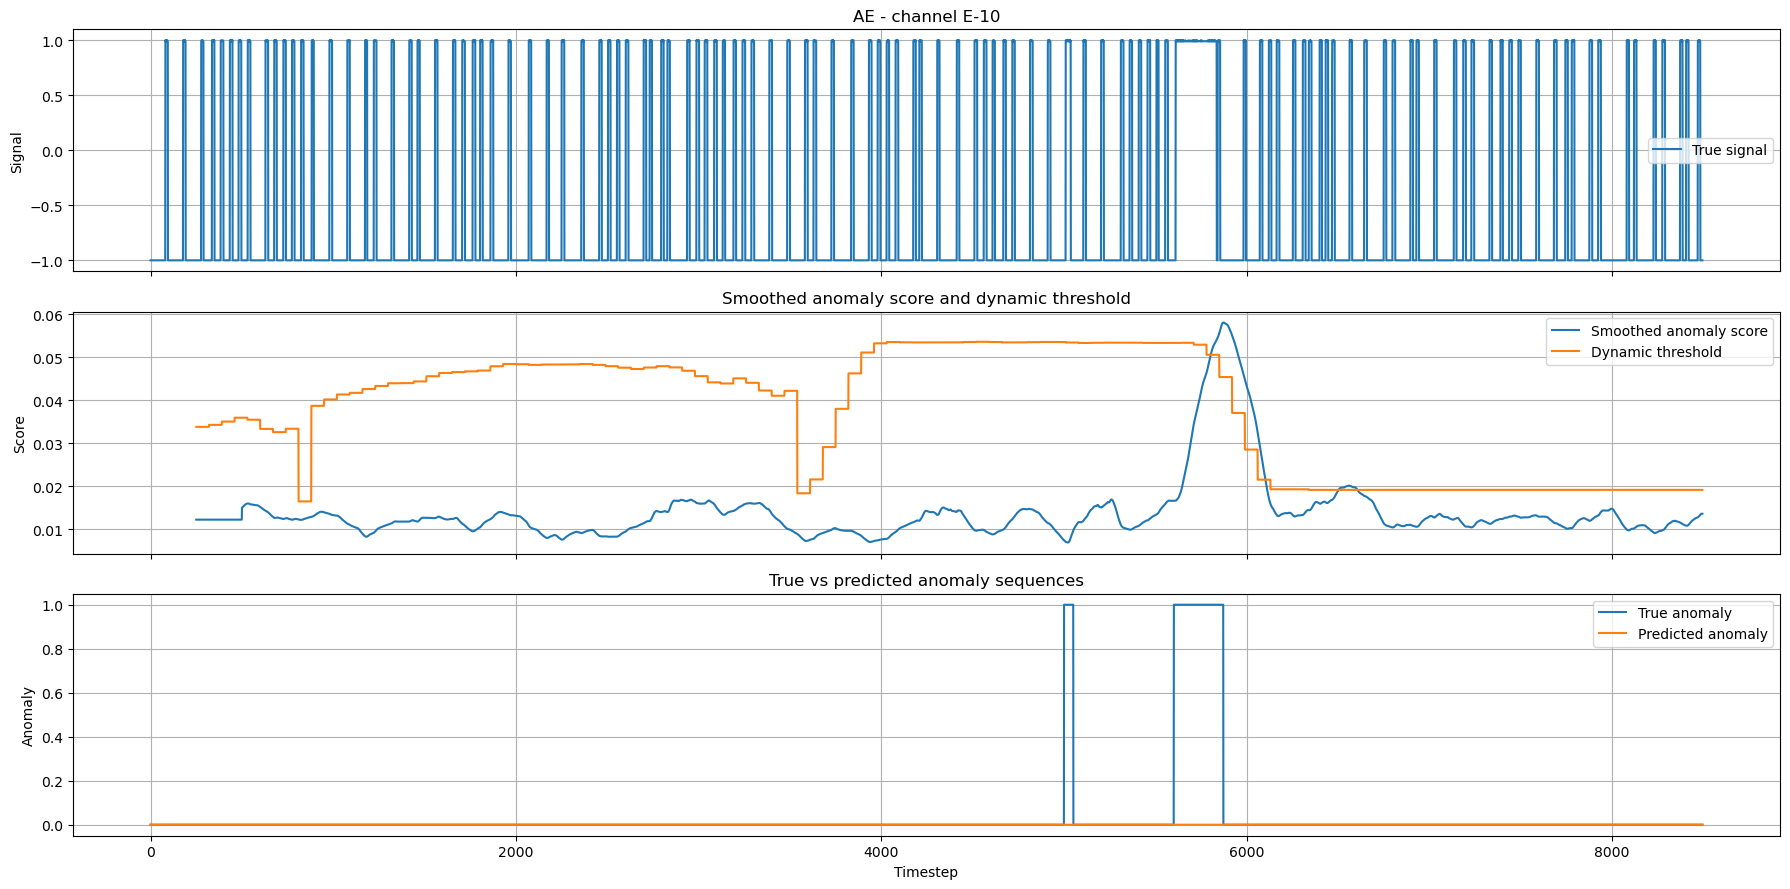

In [64]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=ae_smoothed_scores,
    thresholds=ae_thresholds,
    predictions_binary=ae_predictions_binary,
    model_name="AE"
)

The diagnostic plot for channel E-10 shows that the Random Forest Regressor produces a mostly stable anomaly score over the test sequence, with one dominant increase around the main anomalous region. The true signal is highly discrete and switches frequently between two values, but the forecasting error remains relatively controlled for most of the sequence. This suggests that the model is able to capture the regular switching behaviour of the channel under normal conditions.

The smoothed anomaly score exceeds the dynamic threshold mainly around timestep 5400–5800, where the model detects a compact anomalous sequence. This prediction overlaps well with the main true anomaly interval, although it starts slightly earlier and extends slightly beyond the labelled region. This behaviour is consistent with the use of smoothing and error buffering, which tend to enlarge the detected region around strong error peaks.

A smaller true anomaly appears earlier, around timestep 4750, but it is not detected. In that region, the anomaly score does not rise enough to cross the dynamic threshold. This indicates that the corresponding deviation is either too weak, too short, or not sufficiently different from the normal forecasting errors produced by the model.

Overall, the Random Forest produces a selective prediction pattern: it does not generate many scattered false positives across the sequence, but it mainly reacts to the strongest forecasting-error region. The resulting behaviour is therefore characterized by good detection of the main anomaly, some temporal over-extension of the predicted interval, and a missed short anomaly.

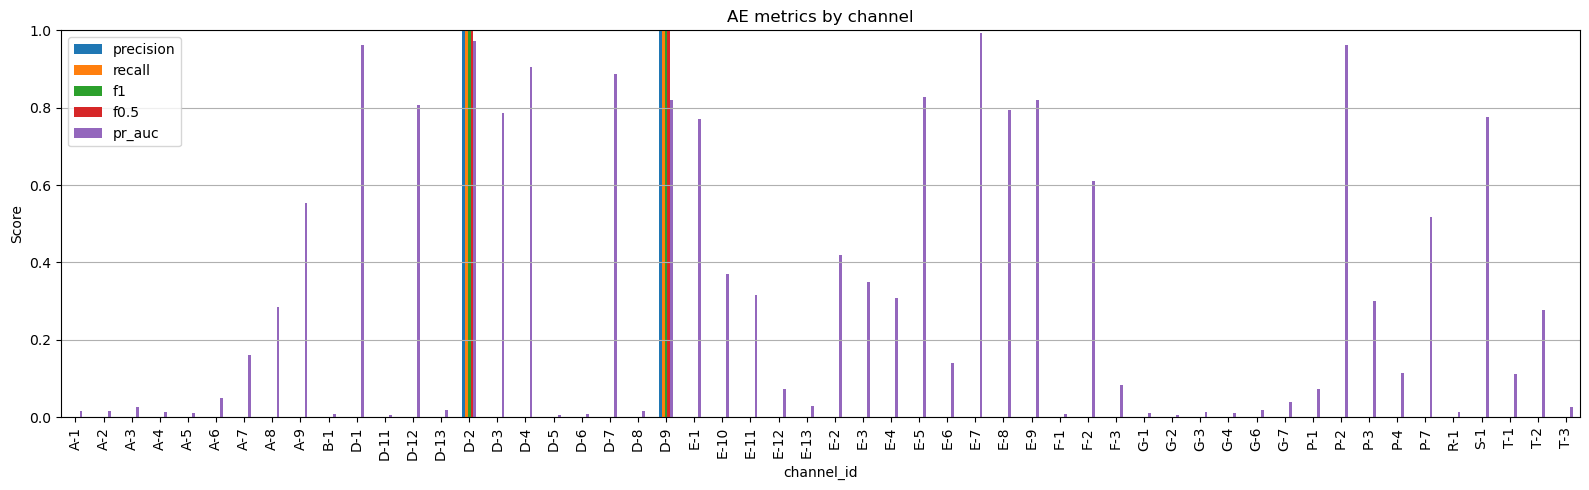

In [65]:
plot_overall_metrics(
    ae_results_df,
    method_name="AE"
)

### Random Forest Regressor

The Random Forest Regressor is introduced as a classical forecasting-based baseline. In this pipeline, the model receives a past multivariate telemetry window and tries to predict the future value of the target signal. Therefore, differently from reconstruction-based models such as AutoEncoders or VAEs, the anomaly score is not computed from the reconstruction error of the input window, but from the forecasting error between the predicted value and the observed value.

For each channel, the input window has shape:

`(window_size, n_features)`

Since Random Forests do not process sequences directly, each window is flattened into a single vector:

`(window_size * n_features)`

The model is then trained to predict the future target values associated with that window. At test time, large forecasting errors indicate that the future behaviour of the signal is difficult to predict from its recent past. These errors are interpreted as anomaly scores.

#### Expected behaviour

The Random Forest is expected to provide a simple but informative non-neural baseline. Since it is an ensemble of decision trees, it can model nonlinear relationships between the variables in the telemetry window without requiring gradient-based training. This makes it a useful reference point before moving to neural forecasting models.

However, Random Forests do not explicitly model temporal order. After flattening, the model sees the window as a fixed vector of lagged values, but it does not have a recurrent structure and does not learn temporal dynamics in the same way as an LSTM. Therefore, we expect it to capture short-term nonlinear dependencies, but potentially struggle with more complex temporal patterns.

If the Random Forest performs competitively, this suggests that much of the predictive information is already contained in the fixed lagged representation. If it performs clearly worse than the neural regressors, this supports the need for more flexible forecasting models.


#### Connection with the MLP Regressor

The Random Forest Regressor is directly connected to the MLP Regressor used in the next section. Both models follow the same forecasting formulation:

`past multivariate window → future target value`

Both models also require the temporal window to be flattened before prediction. The main difference is the learning mechanism. The Random Forest learns an ensemble of decision trees, while the MLP learns a parametric nonlinear function through backpropagation.

For this reason, the Random Forest is a natural baseline for the MLP Regressor. It allows us to check whether the neural network actually improves over a strong classical model using the same input-output representation.

In [66]:
def flatten_windows(X):
    X = np.asarray(X)
    return X.reshape(X.shape[0], -1)


def train_rf_channel(
    X_train,
    y_train,
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
):
    X_train_flat = flatten_windows(X_train)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=n_jobs
    )

    model.fit(X_train_flat, y_train)

    return model


def predict_rf_channel(model, X_test, batch_size=70):
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    for i in range(0, num_batches + 1):
        prior_idx = i * batch_size
        idx = (i + 1) * batch_size

        if i + 1 == num_batches + 1:
            idx = X_test.shape[0]

        X_test_batch = X_test[prior_idx:idx]

        if len(X_test_batch) == 0:
            continue

        X_test_flat = flatten_windows(X_test_batch)
        y_hat_batch = model.predict(X_test_flat)

        agg_y_hat_batch = aggregate_predictions(
            y_hat_batch,
            method="first"
        )

        y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

### Random Forest detection pipeline

For each SMAP channel, the Random Forest is trained on the normal training sequence and then evaluated on the test sequence. The model predicts future telemetry values from past windows. The absolute forecasting error is used as the raw anomaly score.

The same post-processing pipeline used for the other forecasting-based models is then applied. First, the errors are smoothed with EWMA. Then, dynamic thresholding is used to obtain preliminary binary anomaly predictions. After thresholding, pruning is applied to remove weak anomalous sequences according to the relative separation between candidate anomaly sequences. Finally, the remaining predictions are evaluated with the sequence-aware metrics.

This keeps the comparison with the MLP and LSTM fair, because the difference lies mainly in the forecasting model, while the scoring, smoothing, thresholding, pruning and evaluation stages remain unchanged.

In [67]:
rf_models = {}
rf_predictions = {}
rf_errors = {}
rf_smoothed_errors = {}
rf_predictions_binary = {}
rf_thresholds = {}
rf_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training Random Forest Regressor for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model = train_rf_channel(
        X_train=X_train,
        y_train=y_train,
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    y_hat = predict_rf_channel(
        model=model,
        X_test=X_test,
        batch_size=70
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    rf_models[ch] = model
    rf_predictions[ch] = y_hat
    rf_errors[ch] = errors
    rf_smoothed_errors[ch] = smoothed_errors
    rf_predictions_binary[ch] = y_pred
    rf_thresholds[ch] = thresholds
    rf_metrics[ch] = metrics

    display(metrics)

Training Random Forest Regressor for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.300607,0.0


Training Random Forest Regressor for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.247185,0.017713


Training Random Forest Regressor for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.115327,0.077424


Training Random Forest Regressor for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.145622,0.040627


Training Random Forest Regressor for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.389709,0.0


In [68]:
rf_results_df, rf_summary_df = generate_results_view(rf_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.0,0.000000,0.000000,0.300607,0.000000
1,A-2,1,0,0,1.000000,1.0,1.000000,1.000000,0.247185,0.017713
2,A-3,1,0,0,1.000000,1.0,1.000000,1.000000,0.567473,0.034167
3,A-4,1,0,0,1.000000,1.0,1.000000,1.000000,0.788104,0.026022
4,A-5,1,0,0,1.000000,1.0,1.000000,1.000000,0.011650,0.074738
5,A-6,0,0,1,0.000000,0.0,0.000000,0.000000,0.032562,0.000000
6,A-7,1,1,0,0.500000,1.0,0.666667,0.555556,0.952028,0.101496
7,A-8,1,0,0,1.000000,1.0,1.000000,1.000000,0.285541,0.008368
8,A-9,1,0,0,1.000000,1.0,1.000000,1.000000,0.285343,0.016619
9,B-1,1,0,0,1.000000,1.0,1.000000,1.000000,0.009232,0.052278


TP                               47.000000
FP                               15.000000
FN                               21.000000
precision                         0.758065
recall                            0.691176
f1                                0.723077
f0.5                              0.743671
pr_auc_macro                      0.455908
predicted_anomaly_ratio_macro     0.043744
dtype: float64

In [69]:
save_results(rf_results_df,rf_summary_df,method_name="Random_Forest")

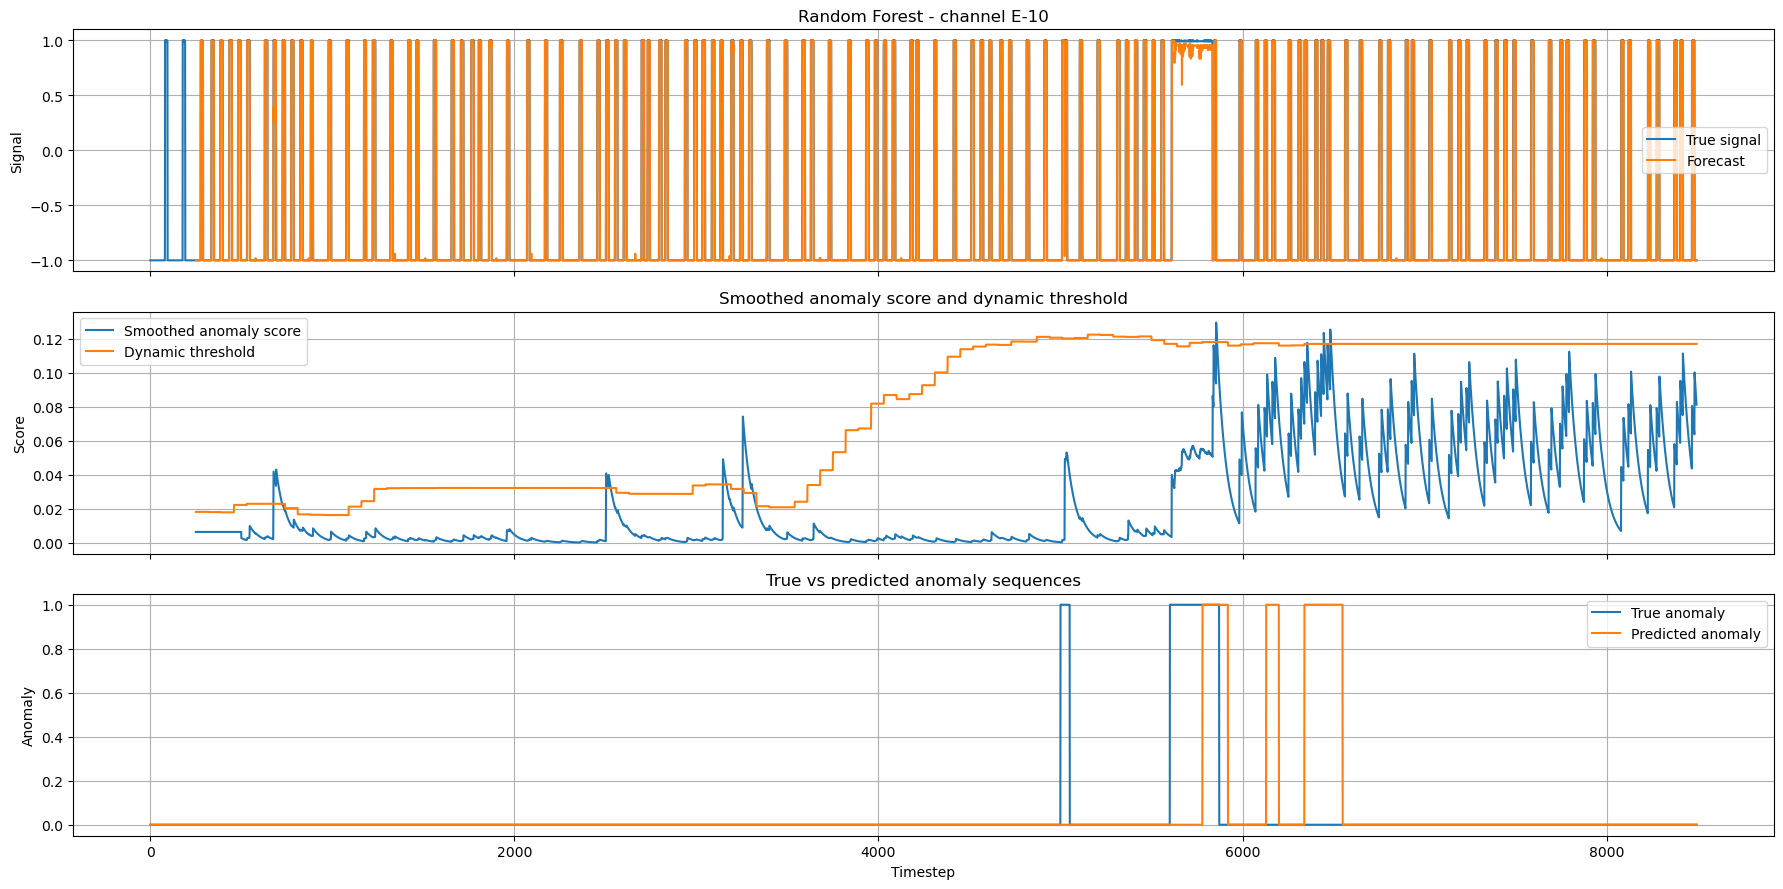

In [70]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=rf_predictions,
    smoothed_errors=rf_smoothed_errors,
    thresholds=rf_thresholds,
    predictions_binary=rf_predictions_binary,
    model_name="Random Forest"
)

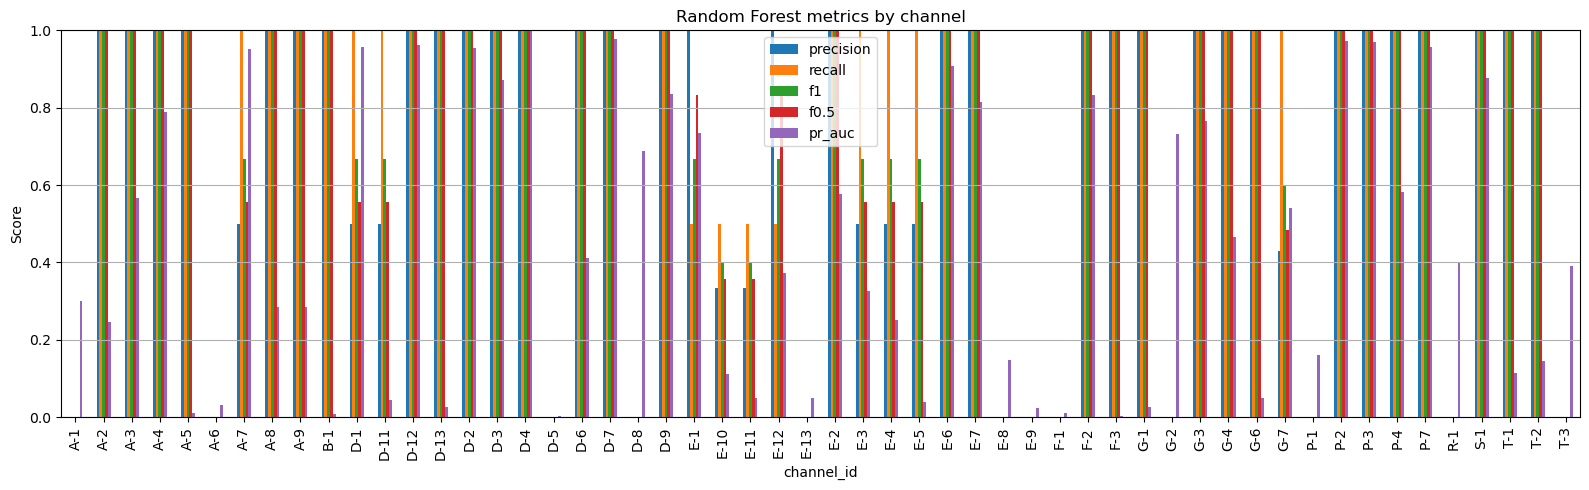

In [71]:
plot_overall_metrics(
    rf_results_df,
    method_name="Random Forest"
)

## Phase 1: Memory-less Deep Learning

Before deploying complex State-of-the-Art sequence models (like LSTMs or Transformers), it is strictly necessary to establish robust baselines. In this section, we introduce a **Multi-Layer Perceptron (MLP) Regressor** as our fundamental baseline for the deep forecasting approach, and **Multi-Layer Perceptron (MLP) Variational Autoencoder** for the reconstruction.

The rationale behind starting with a simple, fully-connected architecture is twofold:

1. **Isolating Temporal Memory:** An MLP requires flattening the temporal window into a single 1D vector, effectively treating time steps as independent spatial features. It lacks a built-in mechanism to capture sequential dependencies (like the hidden state of an RNN). This makes it the perfect **"memory-less" benchmark**. It allows us to measure how much predictive power can be extracted purely from the static local shape of the data, without complex temporal tracking.

2. **Pipeline Validation:** Using a lightweight model allows us to rapidly validate our entire post-processing pipeline—specifically the dynamic thresholding (Telemanom/Hundman style) and EWMA error smoothing—before introducing the computational overhead of Recurrent Neural Networks.

### Multi-Layer Perceptron (MLP) Regressor

The model acts as a deterministic mapping from a historical input window to a future prediction horizon. It is optimized by minimizing the Mean Squared Error (MSE) between its predicted future values ($\hat{y}_i$) and the actual incoming telemetry ($y_i$):

$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

During inference, the anomaly score is derived directly from the absolute forecasting error, specifically, the discrepancy between the model's first predicted step and the true incoming telemetry signal. 

In [72]:
def make_mlp_loader(X_windows, y_windows, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_windows, dtype=torch.float32), 
        torch.tensor(y_windows, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each historical telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is similarly flattened into a vector of length 6250 before being passed to the MLP Regressor. Rather than mapping this input to a latent probability distribution, the network processes the vector through a sequence of deterministic hidden layers to extract complex spatial dependencies.

The flattened input $x$ is transformed through two fully connected layers alternated with Rectified Linear Unit (ReLU) activations and Dropout regularization:

$$
h_1 = \text{Dropout}(\text{ReLU}(W_1 x + b_1))
$$
$$
h_2 = \text{Dropout}(\text{ReLU}(W_2 h_1 + b_2))
$$

where Dropout acts as a vital regularizer to prevent the model from overfitting the high-frequency noise inherent in the spacecraft telemetry data.

A final linear head then maps the deep representation $h_2$ to the desired forecasting dimension, producing the predicted future window $\hat{y} \in \mathbb{R}^{n\_predictions}$:

$$
\hat{y} = W_3 h_2 + b_3
$$

The training objective is a straightforward regression task. The model is optimized by minimizing the Mean Squared Error (MSE) between the predicted horizon and the actual future telemetry values:

$$
\mathcal{L}_{MLP} = \frac{1}{n} \sum_{j=1}^{n} (y_j - \hat{y}_j)^2
$$

where $y_j$ is the ground-truth future sequence. Unlike the VAE, there is no probabilistic regularization term explicitly added to the loss function; the model relies entirely on its architectural constraints (bottlenecks and Dropout) to ensure generalization.

At inference time, the MLP anomaly score is computed at the timestep level as the absolute error between the model's first forecasted step and the true incoming telemetry signal: 
$$e_i = |\hat{y}_{i,0} - y_{i,0}|$$
The resulting score sequence is then processed with the exact same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation. 

In [73]:
class SMAPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_predictions=1, dropout=0.2):
        super().__init__()

        self.sequential = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Linear(hidden_dim // 2, n_predictions)
    
    def forward(self, window):
        window_flat = window.reshape(window.size(0), -1)
        
        features = self.sequential(window_flat)
        y_pred = self.head(features)
        return y_pred

In [77]:
def train_mlp_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_dim=128,
    dropout=0.2,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        y_tr = y_train[:-n_val]
        X_val = X_train[-n_val:]
        y_val = y_train[-n_val:]
    else:
        X_tr = X_train
        y_tr = y_train
        X_val = None
        y_val = None

    train_loader = make_mlp_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_mlp_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = SMAPRegressor(
        input_dim=input_size,
        hidden_dim=hidden_dim,
        n_predictions=n_predictions,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history


def predict_mlp_channel(model, X_test, batch_size=70, device="cpu"):
    model.eval()
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32, device=device)

            y_hat_batch = model(X_tensor).detach().cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(
                y_hat_batch,
                method="first"
            )

            y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

In [78]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [79]:
mlp_models = {}
mlp_histories = {}
mlp_predictions = {}
mlp_errors = {}
mlp_smoothed_errors = {}
mlp_predictions_binary = {}
mlp_thresholds = {}
mlp_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training MLP for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_mlp_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[1] * X_train.shape[2],
        hidden_dim=128,
        dropout=0.2,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    y_hat = predict_mlp_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    mlp_models[ch] = model.to("cpu")
    mlp_histories[ch] = history
    mlp_predictions[ch] = y_hat
    mlp_errors[ch] = errors
    mlp_smoothed_errors[ch] = smoothed_errors
    mlp_predictions_binary[ch] = y_pred
    mlp_thresholds[ch] = thresholds
    mlp_metrics[ch] = metrics

    display(metrics)

Training MLP for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.214149 | val loss: 0.026696
Epoch 02 | train loss: 0.068038 | val loss: 0.006918
Epoch 03 | train loss: 0.043865 | val loss: 0.005946
Epoch 04 | train loss: 0.036334 | val loss: 0.002646
Epoch 05 | train loss: 0.030653 | val loss: 0.002772
Epoch 06 | train loss: 0.029832 | val loss: 0.003721
Epoch 07 | train loss: 0.025531 | val loss: 0.002117
Epoch 08 | train loss: 0.023169 | val loss: 0.001673
Epoch 09 | train loss: 0.021470 | val loss: 0.001956
Epoch 10 | train loss: 0.020694 | val loss: 0.002351
Epoch 11 | train loss: 0.018374 | val loss: 0.005645
Epoch 12 | train loss: 0.018866 | val loss: 0.005564
Epoch 13 | train loss: 0.016758 | val loss: 0.003094
Epoch 14 | train loss: 0.015570 | val loss: 0.001155
Epoch 15 | train loss: 0.014541 | val loss: 0.007840
Epoch 16 | train loss: 0.014574 | val loss: 0.001023
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.306127,0.008111


Training MLP for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.126475 | val loss: 0.043038
Epoch 02 | train loss: 0.057153 | val loss: 0.040052
Epoch 03 | train loss: 0.046884 | val loss: 0.039528
Epoch 04 | train loss: 0.041141 | val loss: 0.041053
Epoch 05 | train loss: 0.038141 | val loss: 0.038125
Epoch 06 | train loss: 0.036722 | val loss: 0.037285
Epoch 07 | train loss: 0.034656 | val loss: 0.039965
Epoch 08 | train loss: 0.032474 | val loss: 0.040776
Epoch 09 | train loss: 0.031142 | val loss: 0.036747
Epoch 10 | train loss: 0.031056 | val loss: 0.041394
Epoch 11 | train loss: 0.029352 | val loss: 0.037021
Epoch 12 | train loss: 0.028231 | val loss: 0.036755
Epoch 13 | train loss: 0.027847 | val loss: 0.038466
Epoch 14 | train loss: 0.027815 | val loss: 0.039901
Epoch 15 | train loss: 0.026977 | val loss: 0.036950
Epoch 16 | train loss: 0.026100 | val loss: 0.038630
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.326707,0.026569


Training MLP for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.096734 | val loss: 0.037314
Epoch 02 | train loss: 0.045243 | val loss: 0.026309
Epoch 03 | train loss: 0.035007 | val loss: 0.026452
Epoch 04 | train loss: 0.029424 | val loss: 0.023901
Epoch 05 | train loss: 0.024760 | val loss: 0.022694
Epoch 06 | train loss: 0.022773 | val loss: 0.025316
Epoch 07 | train loss: 0.021924 | val loss: 0.024719
Epoch 08 | train loss: 0.020415 | val loss: 0.023321
Epoch 09 | train loss: 0.020273 | val loss: 0.023434
Epoch 10 | train loss: 0.020009 | val loss: 0.023925
Epoch 11 | train loss: 0.018527 | val loss: 0.021289
Epoch 12 | train loss: 0.019393 | val loss: 0.023653
Epoch 13 | train loss: 0.018167 | val loss: 0.024699
Epoch 14 | train loss: 0.017920 | val loss: 0.021598
Epoch 15 | train loss: 0.017249 | val loss: 0.023594
Epoch 16 | train loss: 0.016691 | val loss: 0.022256
Epoch 17 | train lo

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.131512,0.051732


Training MLP for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.270564 | val loss: 0.159082
Epoch 02 | train loss: 0.055523 | val loss: 0.146971
Epoch 03 | train loss: 0.038792 | val loss: 0.150337
Epoch 04 | train loss: 0.031687 | val loss: 0.145678
Epoch 05 | train loss: 0.029544 | val loss: 0.145890
Epoch 06 | train loss: 0.026899 | val loss: 0.145014
Epoch 07 | train loss: 0.026300 | val loss: 0.141136
Epoch 08 | train loss: 0.024189 | val loss: 0.141898
Epoch 09 | train loss: 0.022184 | val loss: 0.147157
Epoch 10 | train loss: 0.023769 | val loss: 0.137805
Epoch 11 | train loss: 0.022577 | val loss: 0.137351
Epoch 12 | train loss: 0.020856 | val loss: 0.136012
Epoch 13 | train loss: 0.019851 | val loss: 0.133989
Epoch 14 | train loss: 0.019507 | val loss: 0.137531
Epoch 15 | train loss: 0.018922 | val loss: 0.134279
Epoch 16 | train loss: 0.018379 | val loss: 0.134870
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.304902,0.008125


Training MLP for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.204675 | val loss: 0.010358
Epoch 02 | train loss: 0.047103 | val loss: 0.003610
Epoch 03 | train loss: 0.033914 | val loss: 0.000955
Epoch 04 | train loss: 0.027089 | val loss: 0.001424
Epoch 05 | train loss: 0.025777 | val loss: 0.002759
Epoch 06 | train loss: 0.023653 | val loss: 0.000624
Epoch 07 | train loss: 0.020973 | val loss: 0.000286
Epoch 08 | train loss: 0.019781 | val loss: 0.001176
Epoch 09 | train loss: 0.018211 | val loss: 0.000264
Epoch 10 | train loss: 0.018581 | val loss: 0.011432
Epoch 11 | train loss: 0.018049 | val loss: 0.000249
Epoch 12 | train loss: 0.018693 | val loss: 0.000240
Epoch 13 | train loss: 0.016949 | val loss: 0.002443
Epoch 14 | train loss: 0.015519 | val loss: 0.001174
Epoch 15 | train loss: 0.015583 | val loss: 0.000254
Epoch 16 | train loss: 0.013880 | val loss: 0.002995
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.179682,0.0


In [80]:
mlp_results_df, mlp_summary_df = generate_results_view(mlp_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.306127,0.008111
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.326707,0.026569
2,A-3,1,1,0,0.500000,1.000000,0.666667,0.555556,0.465901,0.070653
3,A-4,1,1,0,0.500000,1.000000,0.666667,0.555556,0.468586,0.052045
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011674,0.074738
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.235282,0.071573
6,A-7,1,0,0,1.000000,1.000000,1.000000,1.000000,0.557119,0.038743
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.354118,0.016736
8,A-9,0,1,1,0.000000,0.000000,0.000000,0.000000,0.989024,0.024335
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009269,0.052278


TP                               53.000000
FP                               18.000000
FN                               15.000000
precision                         0.746479
recall                            0.779412
f1                                0.762590
f0.5                              0.752841
pr_auc_macro                      0.446801
predicted_anomaly_ratio_macro     0.047756
dtype: float64

In [81]:
save_results(mlp_results_df, mlp_summary_df,method_name='MLP')

### MLP-Regressor Results Analysis
Upon evaluating the predictive performance and the resulting anomaly detection metrics of the MLP baseline, we observe remarkably high detection capabilities. This strong performance from a simple, memory-less model highlights a fundamental dynamic of forecasting-based anomaly detection: the value of architectural rigidity.

In our pipeline, the anomaly score relies entirely on the model making large, noticeable mistakes during abnormal events. Because the MLP lacks dynamic memory gates or the ability to update a hidden state on the fly, it is inherently rigid. It aggressively learns the global "normal" pattern of the telemetry but goes completely "blind" when presented with sudden, unexpected anomalous shapes. This inability to adapt quickly leads to massive forecasting failures exactly when we need them. These failures translate into sharp, unmistakable error spikes, effectively trivializing the task for our downstream dynamic thresholding algorithm.

Furthermore, the flattened input structure of the MLP grants its dense layers direct, unattenuated access to every single timestamp in the lookback window simultaneously. For satellite telemetry governed by strong short-term autocorrelations, this direct spatial mapping proves to be highly accurate for baseline forecasting.

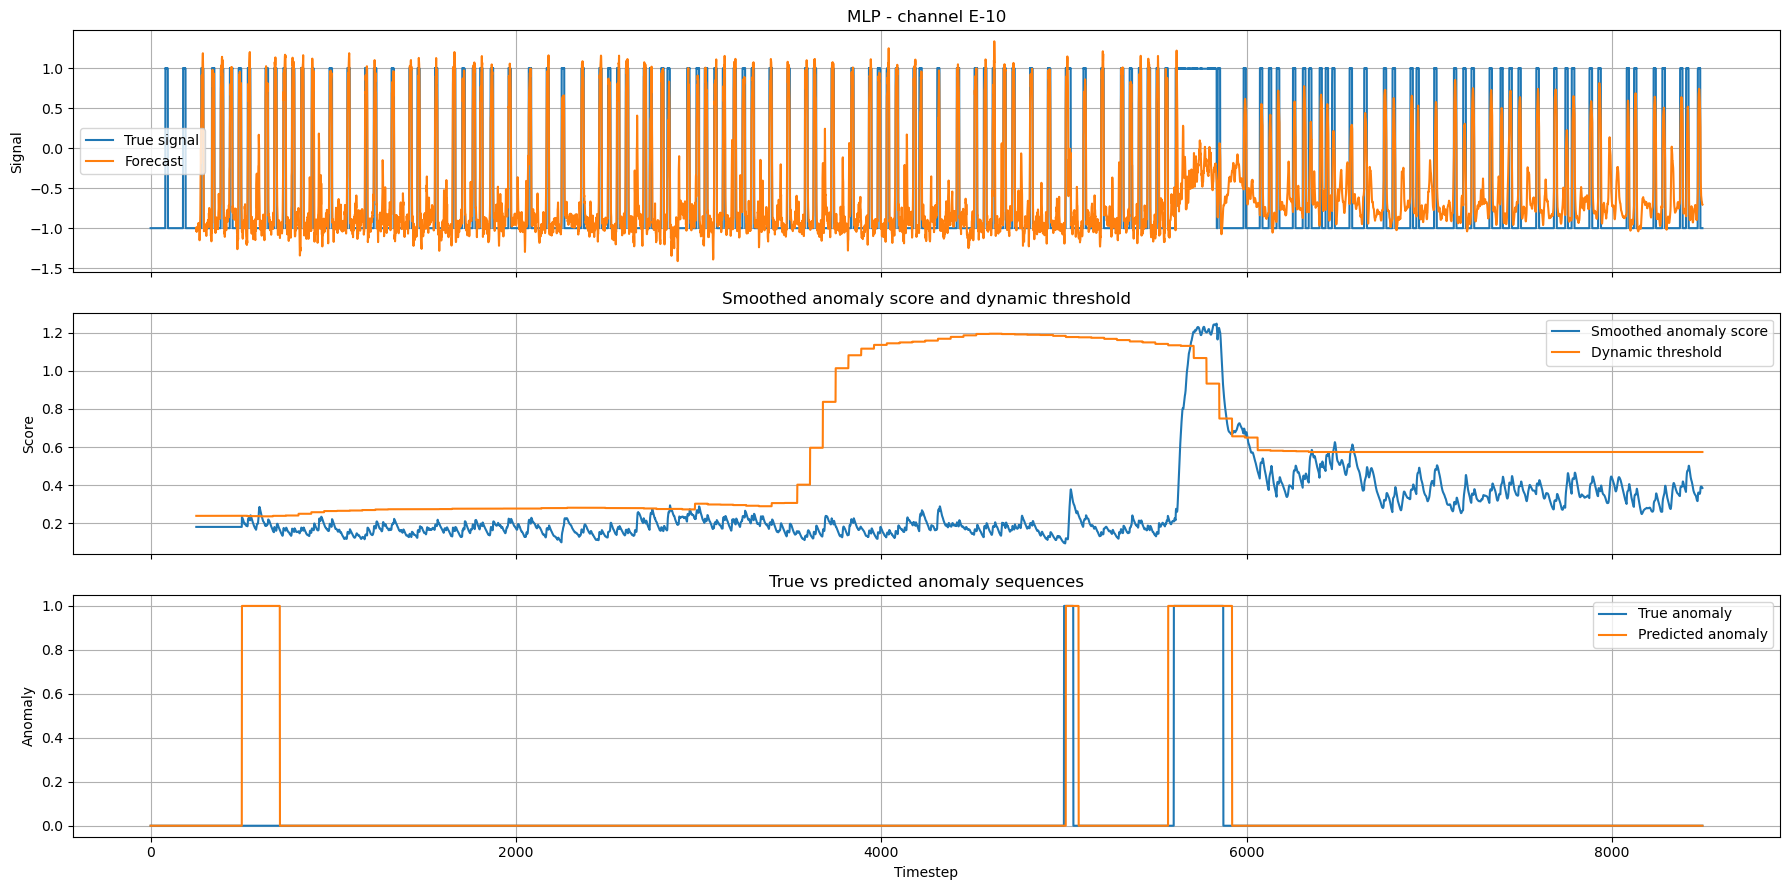

In [82]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=mlp_predictions,
    smoothed_errors=mlp_smoothed_errors,
    thresholds=mlp_thresholds,
    predictions_binary=mlp_predictions_binary,
    model_name="MLP"
)

By analyzing plots, we notice many interesting behaviours of our framework that should be better investigated. 

Around timestep 3500, we observe a sustained elevation in the dynamic threshold (the orange step-function). Notably, this increase does not strictly correlate with a massive spike in the anomaly score itself, but rather with an increase in the *variance* of the background noise. As the sliding window ingests this noisier regime, the standard deviation ($\sigma$) inflates. Multiplied by the optimized $z$-factor, this forces the threshold upward to defensively suppress potential False Positives (Alert Fatigue).

However, this defensive mechanism comes at a severe cost. Because the algorithm relies on a long historical sliding window, the threshold remains artificially elevated long after the noisy period has visually subsided. This creates a "blind spot" or hysteresis effect. 

When a true anomaly occurs later in the sequence (e.g., around timestep 4700-4800), the anomaly score rightfully registers a spike. Yet, because the threshold has not fully decayed from the previous high-variance event, the score fails to breach it. This results in a clear **False Negative**—a missed detection directly caused by the algorithm's lagging memory of past noise. 

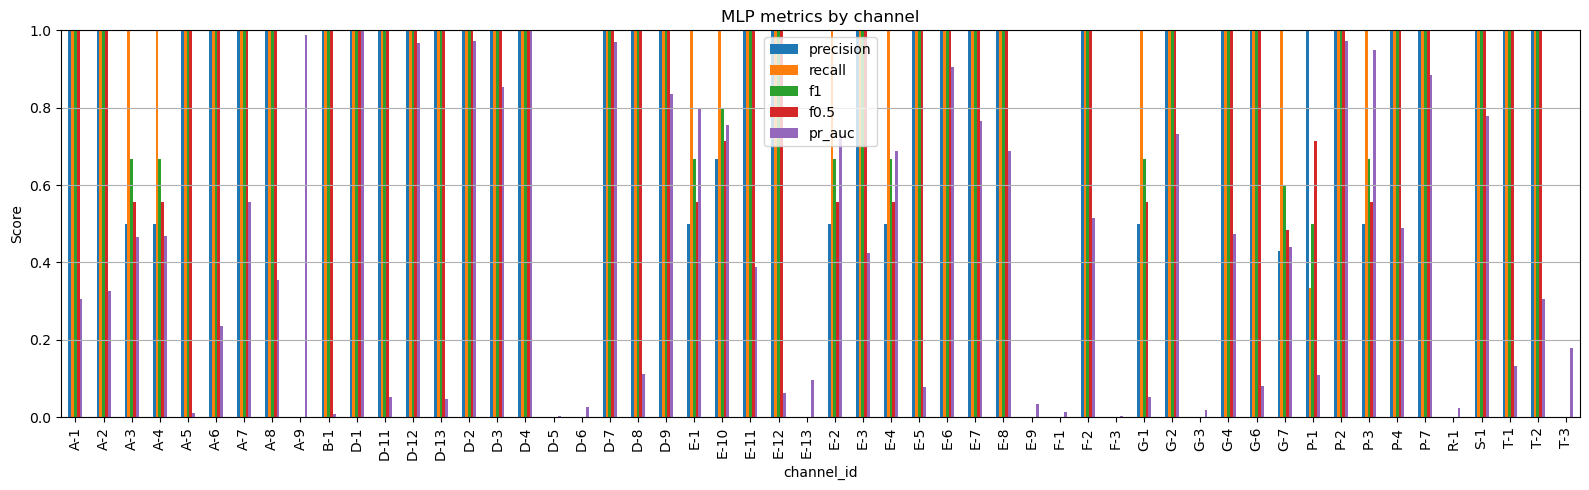

In [83]:
plot_overall_metrics(
    mlp_results_df,
    method_name="MLP"
)

### Multi-Layer Perceptron Variational Autoencoder (MLP-VAE)

The VAE operates as a probabilistic extension of the standard deterministic Autoencoder. Instead of mapping each input window rigidly to a single latent vector, the encoder maps the flattened input to a latent probability distribution, defined mathematically as:

$$
q_\phi(z|x) = \mathcal{N}(\mu(x), \operatorname{diag}(\sigma^2(x)))
$$

A latent sample is then drawn using the reparameterization trick and passed to the decoder, which attempts to reconstruct the original input window. The model is optimized by minimizing a loss function composed of two distinct terms: a reconstruction error and a Kullback-Leibler (KL) divergence regularization term. The reconstruction term encourages high fidelity between the input and the output, while the KL divergence constrains the latent distribution, pushing it toward a standard normal prior:

$$
p(z) = \mathcal{N}(0, I)
$$

During inference, the anomaly score is derived directly from the VAE's reconstruction error. The underlying assumption is that windows generated by nominal telemetry behavior will be mapped to dense, well-learned regions of the latent space and reconstructed accurately, whereas anomalous windows will fall outside this manifold and produce significantly higher reconstruction errors.

In [84]:
class VAEDataset(Dataset):
    def __init__(self, X):
        X = np.asarray(X)
        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)      # Flattened 

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


def make_vae_loader(X, batch_size=64, shuffle=True):
    dataset = VAEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is flattened into a vector of length 6250 before being passed to the VAE. The encoder first maps this vector to an intermediate representation and then produces two latent vectors: the mean $\mu$ and the log-variance $\log \sigma^2$. The use of `logvar` improves numerical stability and ensures that the variance is positive after exponentiation.

The latent vector is sampled through the reparameterization trick:

$$
z = \mu + \sigma \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

In the code, this operation is implemented by the `reparameterize` function. First, the standard deviation is recovered from the predicted log-variance:

$$
\sigma = \exp\left(\frac{1}{2}\log\sigma^2\right)
$$

Then, a random noise vector $\epsilon$ is sampled from a standard normal distribution with the same shape as $\sigma$. The latent vector is obtained as:

$$
z = \mu + \sigma \epsilon
$$

This avoids sampling directly from $\mathcal{N}(\mu, \sigma^2)$. Instead, the randomness is isolated in $\epsilon$, while $\mu$ and $\sigma$ remain differentiable outputs of the encoder. This is necessary to train the VAE with backpropagation.

The decoder then maps $z$ back to the original input dimension, producing a reconstructed version of the flattened telemetry window.

The training objective is:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where $\mathcal{L}_{recon}$ is the mean squared reconstruction error and $\mathcal{L}_{KL}$ penalizes deviations of the learned latent distribution from the standard normal prior. In this project, $\beta$ is kept small so that the model mainly focuses on reconstruction quality while still preserving a regularized latent space.

At inference time, the VAE anomaly score is computed at window level as the reconstruction error plus the weighted KL term. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation used for the LSTM pipeline. This makes the comparison fair at the detection stage, while keeping the modeling assumption different: reconstruction for the VAE, forecasting for the LSTM.

In [85]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_size=16):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.mu_layer = nn.Linear(128, latent_size)
        self.logvar_layer = nn.Linear(128, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x_recon = self.decoder(z)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

#### VAE Loss and Anomaly Score

The VAE loss combines reconstruction quality and latent-space regularization:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where the reconstruction term is the MSE between the input window $x$ and its reconstruction $\hat{x}$:

$$
\mathcal{L}_{recon} = \text{MSE}(\hat{x}, x)
$$

and the KL term penalizes latent distributions that move too far from the standard normal prior $p(z)=\mathcal{N}(0,I)$:

$$
\mathcal{L}_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2
\right)
$$

At inference time, the anomaly score is computed per window as reconstruction error plus the weighted KL term:

$$
s(x) = \text{reconstruction error} + \beta \cdot \text{KL error}
$$

A high score indicates that the window is difficult to reconstruct, has an irregular latent representation, or both. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, pruning, and sequence-based evaluation.

In [86]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

def compute_vae_scores(model, X, batch_size=64, device="cpu"):
    dataset = VAEDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            x_recon, mu, logvar = model(X_batch)
            recon_error = torch.mean((x_recon - X_batch) ** 2, dim=1)
            kl_error = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp(),
                dim=1
            )

            score = recon_error + kl_error * 1e-3
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)

In [90]:
def train_vae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    beta=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_vae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_vae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[1] * X_train.shape[2]

    model = VAE(
        input_size=input_size,
        latent_size=latent_size
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            x_recon, mu, logvar = model(X_batch)

            loss, recon_loss, kl_loss = vae_loss(
                x_recon=x_recon,
                x=X_batch,
                mu=mu,
                logvar=logvar,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_recon += recon_loss.item() * X_batch.size(0)
            train_kl += kl_loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_recon /= len(train_loader.dataset)
        train_kl /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_recon = 0.0
            val_kl = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    x_recon, mu, logvar = model(X_batch)

                    loss, recon_loss, kl_loss = vae_loss(
                        x_recon=x_recon,
                        x=X_batch,
                        mu=mu,
                        logvar=logvar,
                        beta=beta
                    )

                    val_loss += loss.item() * X_batch.size(0)
                    val_recon += recon_loss.item() * X_batch.size(0)
                    val_kl += kl_loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)
            val_recon /= len(val_loader.dataset)
            val_kl /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": val_loss,
                "val_recon_loss": val_recon,
                "val_kl_loss": val_kl
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": np.nan,
                "val_recon_loss": np.nan,
                "val_kl_loss": np.nan
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f}"
            )

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [91]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [92]:
vae_models = {}
vae_histories = {}
vae_scores = {}
vae_smoothed_scores = {}
vae_predictions_binary = {}
vae_thresholds = {}
vae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training VAE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_vae_channel(
        X_train=X_train,
        latent_size=16,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_vae_scores(
        model=model,
        X=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    vae_models[ch] = model.to("cpu")
    vae_histories[ch] = history
    vae_scores[ch] = scores
    vae_smoothed_scores[ch] = smoothed_scores
    vae_predictions_binary[ch] = y_pred
    vae_thresholds[ch] = thresholds
    vae_metrics[ch] = metrics

    display(metrics)

Training VAE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.033217 | val loss: 0.020194
Epoch 02 | train loss: 0.021788 | val loss: 0.019059
Epoch 03 | train loss: 0.021152 | val loss: 0.018652
Epoch 04 | train loss: 0.020782 | val loss: 0.018341
Epoch 05 | train loss: 0.020570 | val loss: 0.018166
Epoch 06 | train loss: 0.020431 | val loss: 0.018090
Epoch 07 | train loss: 0.020267 | val loss: 0.017867
Epoch 08 | train loss: 0.020043 | val loss: 0.017784
Epoch 09 | train loss: 0.019960 | val loss: 0.017808
Epoch 10 | train loss: 0.019941 | val loss: 0.017695
Epoch 11 | train loss: 0.019866 | val loss: 0.017650
Epoch 12 | train loss: 0.019788 | val loss: 0.017742
Epoch 13 | train loss: 0.019763 | val loss: 0.017474
Epoch 14 | train loss: 0.019647 | val loss: 0.017507
Epoch 15 | train loss: 0.019549 | val loss: 0.017383
Epoch 16 | train loss: 0.019471 | val loss: 0.017405
Epoch 17 | train loss: 0.019398 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.02313,0.0


Training VAE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.034972 | val loss: 0.034184
Epoch 02 | train loss: 0.033164 | val loss: 0.033218
Epoch 03 | train loss: 0.030883 | val loss: 0.030547
Epoch 04 | train loss: 0.029157 | val loss: 0.027464
Epoch 05 | train loss: 0.026074 | val loss: 0.025660
Epoch 06 | train loss: 0.024684 | val loss: 0.024838
Epoch 07 | train loss: 0.024106 | val loss: 0.024331
Epoch 08 | train loss: 0.023757 | val loss: 0.024339
Epoch 09 | train loss: 0.023498 | val loss: 0.023811
Epoch 10 | train loss: 0.023354 | val loss: 0.023757
Epoch 11 | train loss: 0.023186 | val loss: 0.023563
Epoch 12 | train loss: 0.023028 | val loss: 0.023567
Epoch 13 | train loss: 0.022917 | val loss: 0.023287
Epoch 14 | train loss: 0.022827 | val loss: 0.023329
Epoch 15 | train loss: 0.022795 | val loss: 0.023347
Epoch 16 | train loss: 0.022648 | val loss: 0.023334
Epoch 17 | train loss: 0.022630 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.012558,0.0


Training VAE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.030686 | val loss: 0.029711
Epoch 02 | train loss: 0.028945 | val loss: 0.029410
Epoch 03 | train loss: 0.028703 | val loss: 0.029043
Epoch 04 | train loss: 0.027640 | val loss: 0.027731
Epoch 05 | train loss: 0.027050 | val loss: 0.027468
Epoch 06 | train loss: 0.026642 | val loss: 0.027175
Epoch 07 | train loss: 0.026341 | val loss: 0.026731
Epoch 08 | train loss: 0.025125 | val loss: 0.024851
Epoch 09 | train loss: 0.023620 | val loss: 0.023777
Epoch 10 | train loss: 0.023110 | val loss: 0.023372
Epoch 11 | train loss: 0.022793 | val loss: 0.023243
Epoch 12 | train loss: 0.022583 | val loss: 0.023049
Epoch 13 | train loss: 0.022392 | val loss: 0.022784
Epoch 14 | train loss: 0.022107 | val loss: 0.022638
Epoch 15 | train loss: 0.021956 | val loss: 0.022623
Epoch 16 | train loss: 0.021929 | val loss: 0.022416
Epoch 17 | train loss: 0.021912 | val l

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.12256,0.0


Training VAE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.023847 | val loss: 0.016673
Epoch 02 | train loss: 0.019426 | val loss: 0.016016
Epoch 03 | train loss: 0.019090 | val loss: 0.015807
Epoch 04 | train loss: 0.017947 | val loss: 0.012741
Epoch 05 | train loss: 0.014878 | val loss: 0.011049
Epoch 06 | train loss: 0.013264 | val loss: 0.010184
Epoch 07 | train loss: 0.012362 | val loss: 0.009709
Epoch 08 | train loss: 0.011379 | val loss: 0.008979
Epoch 09 | train loss: 0.010812 | val loss: 0.008735
Epoch 10 | train loss: 0.010344 | val loss: 0.008207
Epoch 11 | train loss: 0.009797 | val loss: 0.008022
Epoch 12 | train loss: 0.009558 | val loss: 0.007836
Epoch 13 | train loss: 0.009230 | val loss: 0.007827
Epoch 14 | train loss: 0.009044 | val loss: 0.007472
Epoch 15 | train loss: 0.008930 | val loss: 0.007609
Epoch 16 | train loss: 0.008786 | val loss: 0.007460
Epoch 17 | train loss: 0.008680 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.16156,0.0


Training VAE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.014232 | val loss: 0.002307
Epoch 02 | train loss: 0.003714 | val loss: 0.001236
Epoch 03 | train loss: 0.003132 | val loss: 0.000778
Epoch 04 | train loss: 0.002785 | val loss: 0.000552
Epoch 05 | train loss: 0.002596 | val loss: 0.000382
Epoch 06 | train loss: 0.002488 | val loss: 0.000292
Epoch 07 | train loss: 0.002426 | val loss: 0.000244
Epoch 08 | train loss: 0.002387 | val loss: 0.000240
Epoch 09 | train loss: 0.002354 | val loss: 0.000240
Epoch 10 | train loss: 0.002341 | val loss: 0.000183
Epoch 11 | train loss: 0.002319 | val loss: 0.000173
Epoch 12 | train loss: 0.002303 | val loss: 0.000160
Epoch 13 | train loss: 0.002296 | val loss: 0.000137
Epoch 14 | train loss: 0.002282 | val loss: 0.000123
Epoch 15 | train loss: 0.002274 | val loss: 0.000125
Early stopping at epoch 15


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.023151,0.0


In [93]:
vae_results_df,vae_summary_df = generate_results_view(vae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.0,0.0,0.0,0.0,0.023130,0.000000
1,A-2,0,0,1,0.0,0.0,0.0,0.0,0.012558,0.000000
2,A-3,0,0,1,0.0,0.0,0.0,0.0,0.026465,0.000000
3,A-4,0,0,1,0.0,0.0,0.0,0.0,0.011165,0.000000
4,A-5,0,1,1,0.0,0.0,0.0,0.0,0.011750,0.059791
5,A-6,0,0,1,0.0,0.0,0.0,0.0,0.040576,0.000000
6,A-7,0,0,1,0.0,0.0,0.0,0.0,0.160161,0.000000
7,A-8,0,0,1,0.0,0.0,0.0,0.0,0.285283,0.000000
8,A-9,0,0,1,0.0,0.0,0.0,0.0,0.285995,0.000000
9,B-1,0,1,1,0.0,0.0,0.0,0.0,0.007601,0.043565


TP                                5.000000
FP                                3.000000
FN                               63.000000
precision                         0.625000
recall                            0.073529
f1                                0.131579
f0.5                              0.250000
pr_auc_macro                      0.292593
predicted_anomaly_ratio_macro     0.006062
dtype: float64

In [94]:
save_results(vae_results_df,vae_summary_df,method_name='VAE')

### VAE Results Analysis

The VAE reconstruction-based pipeline obtains an average sequence-level precision of 0.593, recall of 0.568, and F1-score of 0.565 across the SMAP channels. The predicted anomaly ratio is approximately 3.99%, meaning that the model marks only a small fraction of the test windows as anomalous. This indicates a selective behavior: the detector does not over-flag the test set, but it also misses a relevant number of labeled anomaly sequences.

The per-channel results show a strongly heterogeneous behavior. Several channels are detected perfectly at sequence level, with precision, recall, and F1-score equal to 1.0. This means that, for those channels, the reconstruction-based score was sufficient to isolate the labeled anomaly interval without generating false positive sequences.

However, many channels have zero recall and zero F1-score. In most of these cases, the predicted anomaly ratio is also zero, meaning that the dynamic thresholding stage did not produce any final anomaly sequence. This suggests that, on these channels, the reconstruction score did not exceed the adaptive threshold strongly enough, even when labeled anomalies were present.

The model also shows some intermediate cases. Channels such as E-1, E-2, E-4, and E-6 detect the true anomaly but also produce one false positive sequence, resulting in precision equal to 0.5. Other channels, such as E-10, E-11, G-7, P-4, and T-3, have high precision but reduced recall, meaning that the detector raises few false alarms but misses part of the labeled anomalous intervals.

The average PR-AUC is 0.290, which is relatively low. This indicates that the continuous VAE anomaly scores do not consistently rank anomalous windows above nominal windows across all channels. Some channels show high PR-AUC but zero final recall, such as D-1 and D-2. This means that the score ranking may contain useful information, but the final dynamic thresholding and post-processing stage can still be too conservative for those channels.

Overall, the VAE provides a meaningful reconstruction-based baseline, but its behavior is highly channel-dependent. The low predicted anomaly ratio and the many zero-recall channels suggest that the current VAE configuration tends to be conservative: it avoids many false positives, but often fails to trigger on labeled anomaly sequences. Further improvements could involve tuning the latent dimension, the KL weight, or the thresholding parameters specifically for reconstruction-based scores.

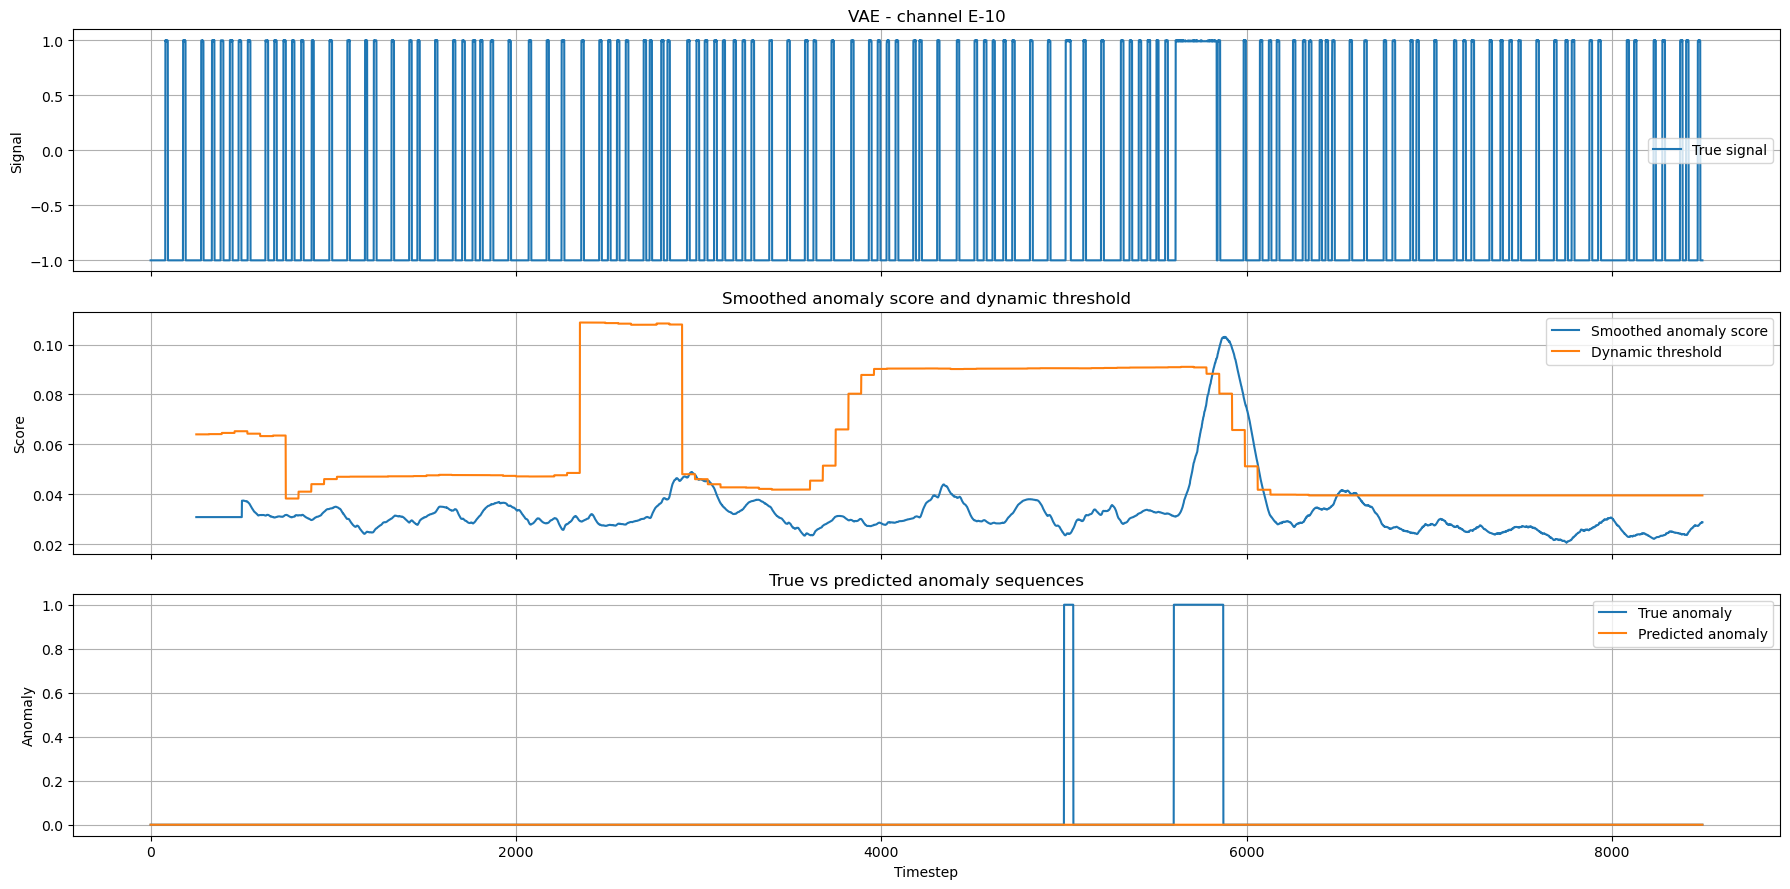

In [95]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=vae_smoothed_scores,
    thresholds=vae_thresholds,
    predictions_binary=vae_predictions_binary,
    model_name="VAE"
)

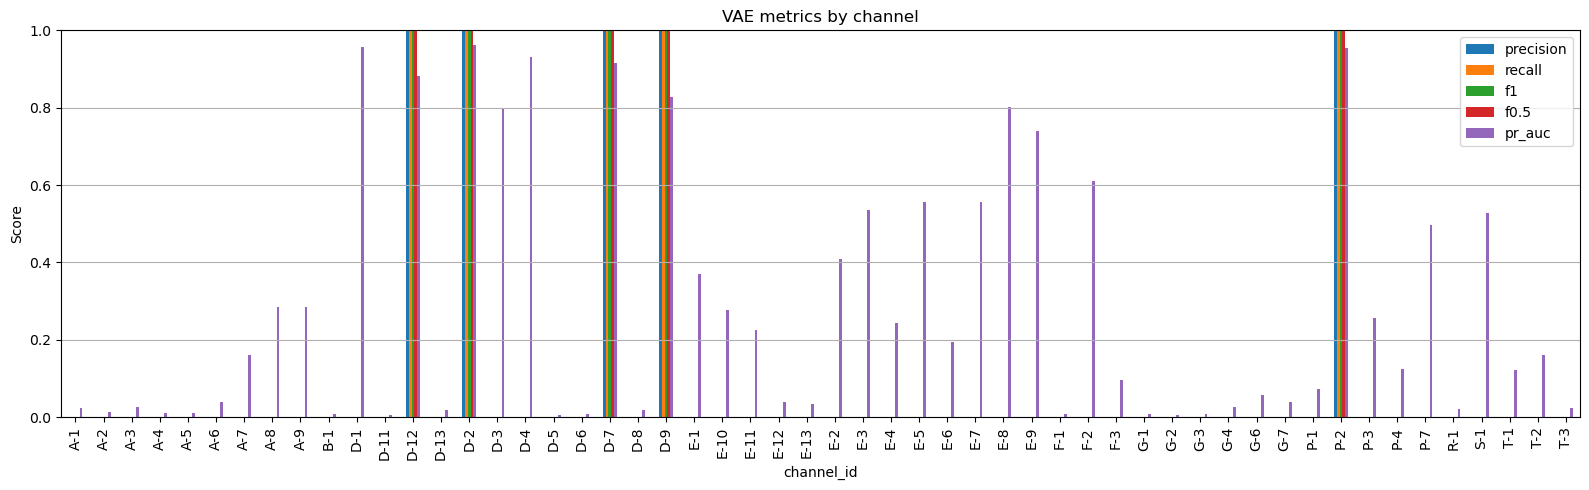

In [96]:
plot_overall_metrics(
    vae_results_df,
    method_name="VAE"
)

## DNN MODELS

The anomaly detection problem is formulated as a forecasting task. Instead of training a model to directly classify each timestep as normal or anomalous, the model is trained to predict the expected future behavior of the main telemetry signal from its recent history and from the associated command variables. The underlying assumption is that, during nominal operation, the future evolution of the signal should be predictable from the previous temporal context. An anomaly is then identified when the observed value deviates significantly from the predicted one.

This formulation is suitable for semi-supervised anomaly detection because the model can be trained only on normal telemetry data, without requiring anomalous examples during training. The anomaly labels are used only for final evaluation. This is particularly relevant for spacecraft telemetry, where failures and anomalous events are rare, heterogeneous, and difficult to model explicitly.

Deep learning models are used because the relationship between telemetry signals and command variables can be nonlinear and temporally dependent. A simple model may fail to capture delayed effects, temporal dependencies, or changes in the signal caused by different command configurations. Sequence models are therefore more appropriate, since they can exploit the ordered structure of the data.

In this project, two forecasting-based neural architectures are considered. The LSTM model is used as a recurrent baseline designed to capture temporal dependencies through hidden states. The Transformer model is used as a more flexible sequence model based on attention mechanisms, allowing the model to weigh different parts of the input window when producing the forecast.

Both models receive as input a sliding window of past multivariate observations and output the next future values of the main telemetry signal. The anomaly score is then computed from the forecasting error. This keeps the detection strategy model-independent: different forecasting models can be compared while using the same downstream anomaly scoring, smoothing, dynamic thresholding, and sequence-based evaluation procedure.

### LSTM Forecasting Architecture

The first deep learning model used in this project is an LSTM-based forecasting model. The input of the network is a sliding window of past multivariate telemetry observations with shape:

$$
X_i \in \mathbb{R}^{250 \times 25}
$$

where 250 is the length of the temporal context and 25 is the number of available features for each SMAP channel. The first feature corresponds to the main telemetry signal, while the remaining features provide command-related contextual information.

The model follows a Telemanom-style architecture based on stacked recurrent layers. The input sequence is processed by a two-layer LSTM with 80 hidden units. The LSTM reads the temporal window step by step and compresses the information contained in the past trajectory into a hidden representation. Dropout is applied as regularization in order to reduce overfitting, especially because each channel is trained independently and some channels have relatively short training sequences.

Only the final hidden representation is passed to a fully connected output layer. The output layer produces a vector of 10 future predictions:

$$
\hat{y}_i \in \mathbb{R}^{10}
$$

corresponding to the next 10 expected values of the main telemetry signal:

$$
\hat{y}_i =
[\hat{x}_{i+250,0}, \hat{x}_{i+251,0}, \ldots, \hat{x}_{i+259,0}]
$$

The model is trained using mean squared error between the predicted and observed future telemetry values. Therefore, the LSTM is not trained to classify anomalies directly. It learns the nominal temporal dynamics of the signal, conditioned on the recent telemetry history and command context. Anomalies are detected only after forecasting, by comparing the predicted signal with the observed one and applying the dynamic thresholding pipeline to the resulting prediction errors.

#### LSTM Forecasting Pipeline

The LSTM model is only the forecasting component of the anomaly detection pipeline. The complete procedure is composed of several sequential steps.

First, for each SMAP channel, the model receives a sliding window of past multivariate telemetry observations and predicts the next 10 future values of the main telemetry signal. This produces a multi-step forecast for each input window.

Since consecutive windows overlap, the same future timestep can be predicted multiple times by different windows. Therefore, the multi-step predictions are aggregated into a single predicted signal within diagonal aggregation strategy. This gives one forecasted value for each evaluated timestep.

The aggregated prediction is then compared with the observed telemetry value. The anomaly score is computed as the absolute forecasting error:

$$
e_t = |\hat{x}_{t,0} - x_{t,0}|
$$

The raw error signal is smoothed using EWMA in order to reduce the effect of isolated noisy peaks and obtain a more stable anomaly score.

The smoothed errors are then processed with dynamic non-parametric thresholding.

After thresholding, post-processing is applied. The detected anomaly candidates are expanded with a temporal error buffer, inverted errors are also checked to capture unusual deviations in the opposite direction, and pruning is used to remove weak anomaly sequences that are not sufficiently separated from the nominal error distribution.

The final binary anomaly predictions are then evaluated using sequence-based metrics, where contiguous anomalous intervals are compared against the labeled anomaly sequences.

In [27]:
class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = ForecastDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [28]:
class LSTMForecaster(nn.Module):
    """
    PyTorch implementation aligned with Telemanom's Keras architecture:
        LSTM(80, return_sequences=True)
        Dropout(0.3)
        LSTM(80, return_sequences=False)
        Dropout(0.3)
        Dense(n_predictions)
        Linear activation
    """

    def __init__(
        self,
        input_size=25,
        hidden_size=80,
        dropout=0.3,
        n_predictions=10
    ):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout2 = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, n_predictions)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        last_hidden = out[:, -1, :]
        last_hidden = self.dropout2(last_hidden)

        y_hat = self.fc(last_hidden)

        return y_hat

In [32]:
def make_train_val_split(X, y, validation_split=0.2):
    """
    Keras validation_split behaviour with shuffle=True in model.fit is not exactly
    reproduced here. This split keeps the last validation_split fraction as validation.

    For time series this is also safer than random validation.
    """

    n = len(X)
    n_val = int(n * validation_split)

    if n_val == 0:
        return X, y, None, None

    X_tr = X[:-n_val]
    y_tr = y[:-n_val]

    X_val = X[-n_val:]
    y_val = y[-n_val:]

    return X_tr, y_tr, X_val, y_val


def train_lstm_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_size=80,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    """
    Train LSTM forecaster with parameters:
    - 35 max epochs
    - batch size 64
    - validation split 0.2
    - early stopping with patience 10 and min_delta 0.0003
    """

    X_tr, y_tr, X_val, y_val = make_train_val_split(
        X_train,
        y_train,
        validation_split=validation_split
    )

    train_loader = make_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=hidden_size,
        dropout=dropout,
        n_predictions=n_predictions
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {k: v.detach().cpu().clone() 
                  for k, v in model.state_dict().items()
                  }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

            del X_batch,y_batch,pred,loss

        if device.type == "mps":
            torch.mps.empty_cache()
        if device.type == "cuda":
            torch.cuda.empty_cache()

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

                    del X_batch,y_batch,pred,loss

            if device.type == "mps":
                torch.mps.empty_cache()
            if device.type == "cuda":
                torch.cuda.empty_cache()

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch + 1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch + 1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

### Training and Detection Strategy Across SMAP Channels

The LSTM model is trained independently for each SMAP channel. This choice is motivated by the structure of the dataset: each channel represents a different telemetry stream, with its own signal dynamics, command context, training length, and anomaly patterns. A single global model would implicitly assume that all channels share the same temporal behavior, which is not necessarily true. Training one model per channel allows the forecasting model to specialize on the nominal dynamics of that specific telemetry signal.

For each channel, the LSTM is trained to predict the next 10 values of the main telemetry signal from the previous 250 multivariate observations. After prediction, the overlapping multi-step forecasts are aggregated into a single predicted signal, which is compared with the observed telemetry value to obtain the forecasting error.

The global results should be interpreted with caution. Averaged metrics across all channels provide a compact view of the overall behavior, but they do not tell the whole story. Some channels may be easier to forecast and detect, while others may have shorter training sequences, weaker signal structure, more constant features, or more difficult anomaly patterns. For this reason, both global metrics and per-channel metrics should be inspected.

Precision, recall, and F1-score summarize sequence-level detection performance after post-processing. PR-AUC provides an additional threshold-independent diagnostic based on the continuous anomaly scores before final binary decisions. The predicted anomaly ratio is used as a sanity check: very low values may indicate that the pipeline is missing most anomalies, while very high values may indicate excessive false alarms. The goal of this stage is to evaluate the complete LSTM-based detection pipeline before comparing it with alternative forecasting models such as Transformers.

In [30]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [33]:
lstm_models = {}
lstm_histories = {}
lstm_predictions = {}
lstm_errors = {}
lstm_smoothed_errors = {}
lstm_predictions_binary = {}
lstm_thresholds = {}
lstm_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[2],
        hidden_size=80,
        dropout=0.3,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()
    
    y_hat = batch_predict_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    # Align y_test with y_hat
    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    # y_pred has been shifted by l_s and is in raw-test coordinates.
    # labels_data[ch] should also be in raw-test coordinates.
    labels_eval = labels[:len(y_pred)]

    # For PR-AUC, pad scores to raw-coordinate length.
    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_models[ch] = model.to("cpu")
    lstm_histories[ch] = history
    lstm_predictions[ch] = y_hat
    lstm_errors[ch] = errors
    lstm_smoothed_errors[ch] = smoothed_errors
    lstm_predictions_binary[ch] = y_pred
    lstm_thresholds[ch] = thresholds
    lstm_metrics[ch] = metrics

    display(metrics)

Training LSTM for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.361177 | val loss: 0.023353
Epoch 02 | train loss: 0.034851 | val loss: 0.000977
Epoch 03 | train loss: 0.024712 | val loss: 0.000318
Epoch 04 | train loss: 0.020493 | val loss: 0.000456
Epoch 05 | train loss: 0.017297 | val loss: 0.000247
Epoch 06 | train loss: 0.016000 | val loss: 0.000701
Epoch 07 | train loss: 0.014197 | val loss: 0.000174
Epoch 08 | train loss: 0.012815 | val loss: 0.000049
Epoch 09 | train loss: 0.011609 | val loss: 0.000161
Epoch 10 | train loss: 0.011119 | val loss: 0.000045
Epoch 11 | train loss: 0.010169 | val loss: 0.000045
Epoch 12 | train loss: 0.009874 | val loss: 0.000499
Epoch 13 | train loss: 0.009557 | val loss: 0.000077
Early stopping at epoch 13


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.304518,0.016222


Training LSTM for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.273761 | val loss: 0.205055
Epoch 02 | train loss: 0.131084 | val loss: 0.119233
Epoch 03 | train loss: 0.076738 | val loss: 0.061124
Epoch 04 | train loss: 0.050968 | val loss: 0.049350
Epoch 05 | train loss: 0.046159 | val loss: 0.051067
Epoch 06 | train loss: 0.041885 | val loss: 0.044329
Epoch 07 | train loss: 0.041084 | val loss: 0.040682
Epoch 08 | train loss: 0.036824 | val loss: 0.037427
Epoch 09 | train loss: 0.036502 | val loss: 0.035546
Epoch 10 | train loss: 0.035034 | val loss: 0.037579
Epoch 11 | train loss: 0.034158 | val loss: 0.036092
Epoch 12 | train loss: 0.033183 | val loss: 0.034357
Epoch 13 | train loss: 0.033807 | val loss: 0.036082
Epoch 14 | train loss: 0.033003 | val loss: 0.036482
Epoch 15 | train loss: 0.032315 | val loss: 0.035546
Epoch 16 | train loss: 0.031804 | val loss: 0.035594
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.29425,0.026569


Training LSTM for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.176208 | val loss: 0.117079
Epoch 02 | train loss: 0.070765 | val loss: 0.033254
Epoch 03 | train loss: 0.036986 | val loss: 0.025915
Epoch 04 | train loss: 0.031436 | val loss: 0.018077
Epoch 05 | train loss: 0.029279 | val loss: 0.021057
Epoch 06 | train loss: 0.028431 | val loss: 0.019284
Epoch 07 | train loss: 0.027104 | val loss: 0.019076
Epoch 08 | train loss: 0.027072 | val loss: 0.018914
Epoch 09 | train loss: 0.026887 | val loss: 0.019254
Epoch 10 | train loss: 0.026220 | val loss: 0.020249
Epoch 11 | train loss: 0.025235 | val loss: 0.017945
Epoch 12 | train loss: 0.026272 | val loss: 0.018308
Epoch 13 | train loss: 0.024888 | val loss: 0.019367
Epoch 14 | train loss: 0.023538 | val loss: 0.018636
Early stopping at epoch 14


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.107971,0.0


Training LSTM for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.438548 | val loss: 0.306347
Epoch 02 | train loss: 0.241679 | val loss: 0.180426
Epoch 03 | train loss: 0.159490 | val loss: 0.110828
Epoch 04 | train loss: 0.101557 | val loss: 0.064663
Epoch 05 | train loss: 0.072586 | val loss: 0.092499
Epoch 06 | train loss: 0.081096 | val loss: 0.054419
Epoch 07 | train loss: 0.063603 | val loss: 0.049256
Epoch 08 | train loss: 0.044047 | val loss: 0.030201
Epoch 09 | train loss: 0.042518 | val loss: 0.024145
Epoch 10 | train loss: 0.036547 | val loss: 0.023312
Epoch 11 | train loss: 0.032350 | val loss: 0.028499
Epoch 12 | train loss: 0.024083 | val loss: 0.020747
Epoch 13 | train loss: 0.025419 | val loss: 0.023131
Epoch 14 | train loss: 0.021373 | val loss: 0.023702
Epoch 15 | train loss: 0.017760 | val loss: 0.022693
Epoch 16 | train loss: 0.018242 | val loss: 0.021606
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.120089,0.0


Training LSTM for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.398497 | val loss: 0.025243
Epoch 02 | train loss: 0.033780 | val loss: 0.000743
Epoch 03 | train loss: 0.023019 | val loss: 0.000589
Epoch 04 | train loss: 0.019395 | val loss: 0.000551
Epoch 05 | train loss: 0.016205 | val loss: 0.000550
Epoch 06 | train loss: 0.014506 | val loss: 0.000237
Epoch 07 | train loss: 0.013150 | val loss: 0.000258
Epoch 08 | train loss: 0.011431 | val loss: 0.000714
Epoch 09 | train loss: 0.010782 | val loss: 0.000441
Epoch 10 | train loss: 0.010075 | val loss: 0.000270
Epoch 11 | train loss: 0.009392 | val loss: 0.000450
Epoch 12 | train loss: 0.009409 | val loss: 0.000454
Epoch 13 | train loss: 0.008414 | val loss: 0.000391
Epoch 14 | train loss: 0.008610 | val loss: 0.000313
Epoch 15 | train loss: 0.007840 | val loss: 0.000272
Epoch 16 | train loss: 0.007803 | val loss: 0.000669
Early stopping at 

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,1,1.0,0.5,0.666667,0.833333,0.390523,0.029642


In [34]:
lstm_result_df,lstm_summary_df = generate_results_view(lstm_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.304518,0.016222
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.294250,0.026569
2,A-3,1,0,0,1.000000,1.000000,1.000000,1.000000,0.549366,0.025625
3,A-4,1,0,0,1.000000,1.000000,1.000000,1.000000,0.573504,0.026022
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011646,0.074738
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.477677,0.048616
6,A-7,1,2,0,0.333333,1.000000,0.500000,0.384615,0.957681,0.092101
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.300025,0.008368
8,A-9,1,0,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.008310
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009955,0.052278


TP                               53.000000
FP                               17.000000
FN                               15.000000
precision                         0.757143
recall                            0.779412
f1                                0.768116
f0.5                              0.761494
pr_auc_macro                      0.527305
predicted_anomaly_ratio_macro     0.046070
dtype: float64

In [42]:
bad_channels = ["D-5", "D-2", "B-1", "D-13", "A-5", "A-9"]

for ch in bad_channels:
    y_tr = y_train_data[ch].reshape(-1)
    y_te = y_test_data[ch][:, 0]

    print("\n", ch)
    print("train target min/max:", y_tr.min(), y_tr.max())
    print("test target min/max:", y_te.min(), y_te.max())
    print("train target mean:", y_tr.mean())
    print("test target mean:", y_te.mean())
    print("train frac > 0:", np.mean(y_tr > 0))
    print("test frac > 0:", np.mean(y_te > 0))



 D-5
train target min/max: 0.999 1.0
test target min/max: -1.0 1.0
train target mean: 0.9993986104005415
test target mean: -0.9967462041651172
train frac > 0: 1.0
test frac > 0: 0.0005428881650380022

 D-2
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.08698260347930414
train frac > 0: 0.0
test frac > 0: 0.45650869826034796

 B-1
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.24023638232271327
train frac > 0: 0.0
test frac > 0: 0.37988180883864336

 D-13
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.3202755639605565
train frac > 0: 0.0
test frac > 0: 0.33418884236120494

 A-5
train target min/max: -1.0 -0.9990645161290324
test target min/max: -0.9999999999999999 0.9999999999999998
train target mean: -0.9997236389996376
test target mean: -0.35039532562661446
train frac > 0: 0.0
test frac > 0: 0.4342431761786

A closer inspection of the forecasting errors shows that the LSTM does not fail uniformly across channels. For several problematic channels, the training and test target distributions are strongly mismatched. For example, in channel D-5 the training target is almost always equal to +1, while the test target is almost always equal to -1. As a consequence, the model learns to predict the dominant training regime and produces forecasts close to +1 throughout the test sequence, leading to very large prediction errors.

A similar behaviour is observed in channels such as D-2, B-1, D-13 and A-5, where the training target is almost constantly -1, while the test sequence contains a substantial fraction of positive values. In these cases, the model has not observed the relevant operating regimes during training and therefore cannot be expected to generalize reliably to them.

The anomaly detector ultimately depends on the quality of the forecasting errors. If the predictor systematically fails because the training set does not represent the normal regimes appearing in the test set, the smoothed error signal becomes less informative and the dynamic thresholding stage cannot fully recover.

Therefore, the main limitation is not only the LSTM architecture or the thresholding method, but also the representativeness of the training data. For some channels, the train-test split produces a regime mismatch: the model is trained on an almost constant state and tested on a different or more variable operating regime. This makes the forecasting task ill-posed for those channels and directly affects anomaly detection performance.

### LSTM Results Discussion

The LSTM-based forecasting pipeline obtains an average sequence-level precision of 0.583, recall of 0.735, and F1-score of 0.625 across the SMAP channels. These results indicate that the model is able to detect a large fraction of the labeled anomalous sequences, while still producing a moderate number of false alarm sequences. The recall value is higher than precision, meaning that the detector is more effective at capturing true anomalous intervals than at avoiding false positives.

The average F1-score of 0.625 suggests a reasonable balance between detection capability and false alarm control. Since the evaluation is sequence-based, this score should be interpreted at the anomaly-event level rather than at the single-timestep level. The predicted anomaly ratio is approximately 5.63%, meaning that the final pipeline marks only a limited portion of the evaluated timesteps as anomalous. This suggests that the detector is not degenerate: it is not classifying most of the test set as anomalous. At the same time, the precision value indicates that some predicted anomaly sequences still do not overlap with labeled anomalies.

The per-channel results show heterogeneous behavior across SMAP telemetry streams. Several channels reach perfect sequence-level precision, recall, and F1-score, meaning that all labeled anomaly sequences are detected without producing additional false alarm sequences. However, the model also fails completely on some channels, where precision, recall, and F1-score are equal to zero. In these cases, the detector either does not trigger any anomaly or triggers only false positives without overlapping the true labeled anomalous intervals.

This confirms that the average performance is driven by a mixture of successful and difficult channels. Some telemetry streams are easier to forecast and detect, while others likely have weaker anomaly-score separation, more complex dynamics, shorter useful training history, or anomaly patterns that are not well captured by the LSTM forecasting error. Channels with high recall but low precision indicate that the model detects the true anomalous sequences, but also generates additional false positive sequences.

The PR-AUC is 0.489 and varies substantially across channels. This metric should be interpreted separately from the sequence-level metrics, because PR-AUC evaluates the ranking quality of the continuous anomaly scores before the final binary decision, while precision, recall, and F1-score are computed after dynamic thresholding and post-processing. A moderate PR-AUC combined with stronger sequence-level recall means that the final thresholding strategy can still identify many labeled anomaly intervals, even if the continuous scores are not always globally well ranked.

Overall, the LSTM model provides a solid forecasting-based anomaly detection baseline. The results are stronger on recall than on precision and are clearly channel-dependent. Further improvements should focus on reducing false positives and improving the ranking quality of the anomaly scores, especially on channels where the current pipeline either misses the anomaly completely or produces excessive predicted anomaly sequences.

In [35]:
save_results(lstm_result_df,lstm_summary_df,method_name='LSTM')

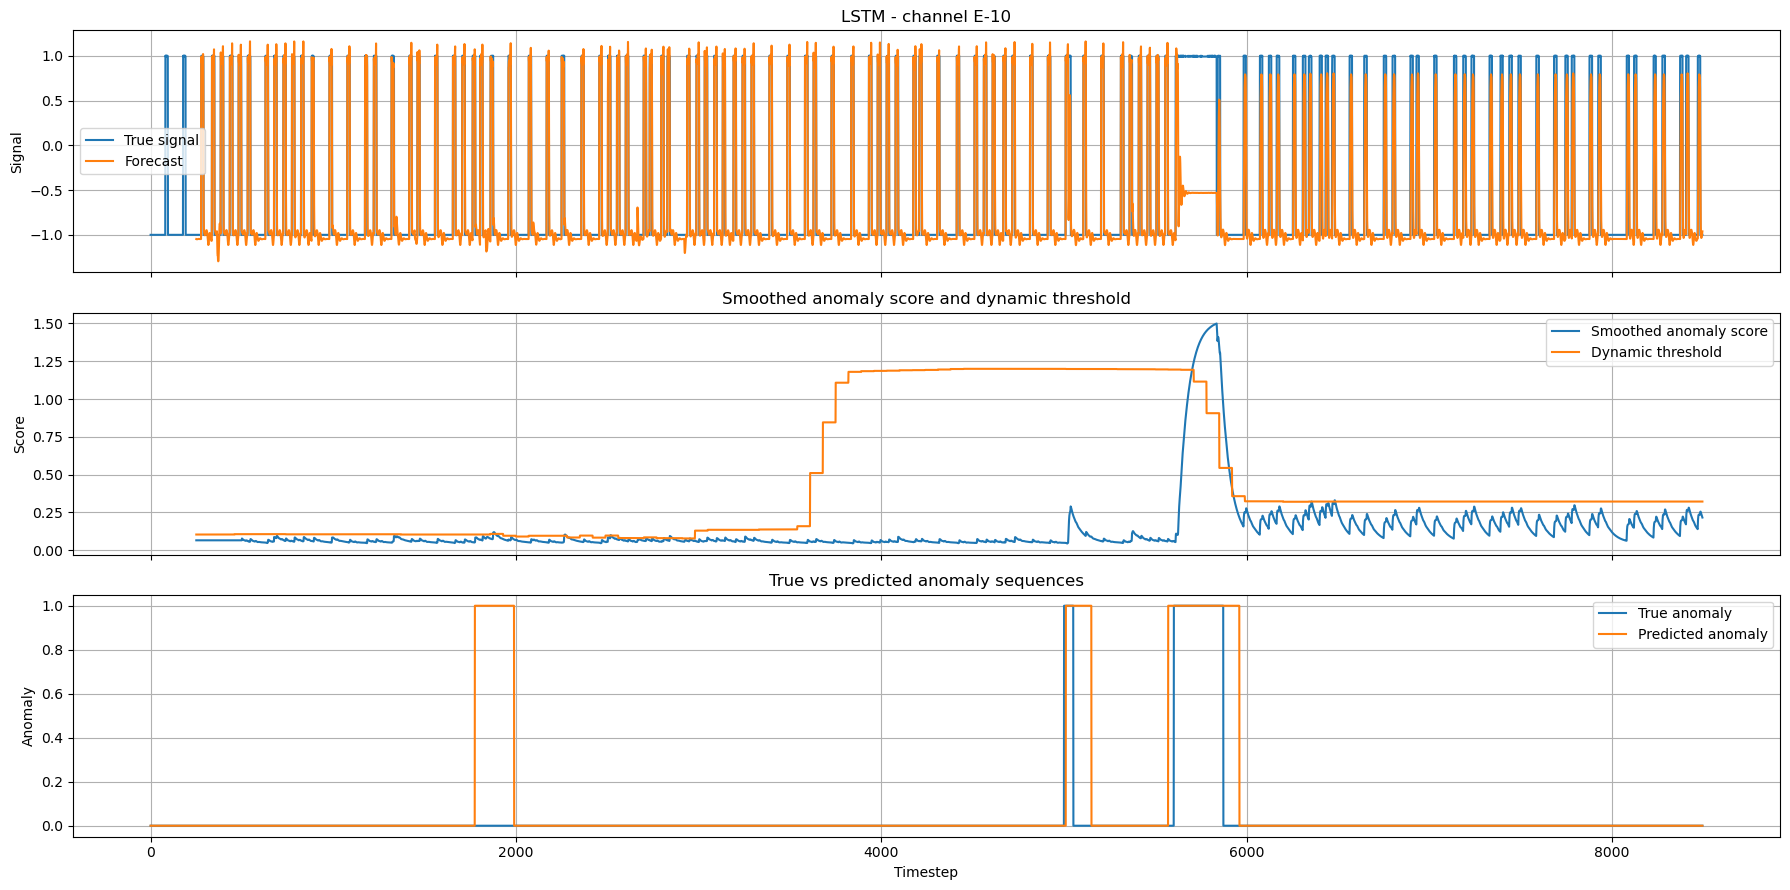

In [36]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=lstm_predictions,
    smoothed_errors=lstm_smoothed_errors,
    thresholds=lstm_thresholds,
    predictions_binary=lstm_predictions_binary,
    model_name="LSTM"
)

The diagnostic plot for channel E-10 shows that the LSTM is able to follow part of the binary switching behaviour of the signal, but the forecast remains noisy and imperfect over the whole sequence. This produces a relatively high and oscillatory forecasting error even in regions where no anomaly is labelled.

The smoothed anomaly score stays below the dynamic threshold for most of the test sequence, despite the presence of frequent local error peaks. The most relevant increase occurs around timestep 5400–5700, where the score sharply rises and crosses the threshold. This region corresponds to the main labelled anomaly interval, which is correctly detected by the model.

The predicted anomalous interval overlaps well with the main true anomaly, although it is slightly extended because of smoothing and error buffering. The shorter anomaly around timestep 4750 is also partially detected, but the predicted interval is very narrow and slightly shifted. This suggests that the LSTM reacts to this local deviation, but the anomaly score is not strong or stable enough to produce a wider detection.

Overall, the LSTM produces meaningful anomaly detections around the labelled anomalous regions, but its forecasting errors are noisier than ideal. The dynamic thresholding and pruning steps help suppress most scattered false positives, keeping the final predictions compact. The behaviour is therefore characterized by detection of the main anomaly, partial detection of the shorter anomaly, and a generally noisy but controlled anomaly score.

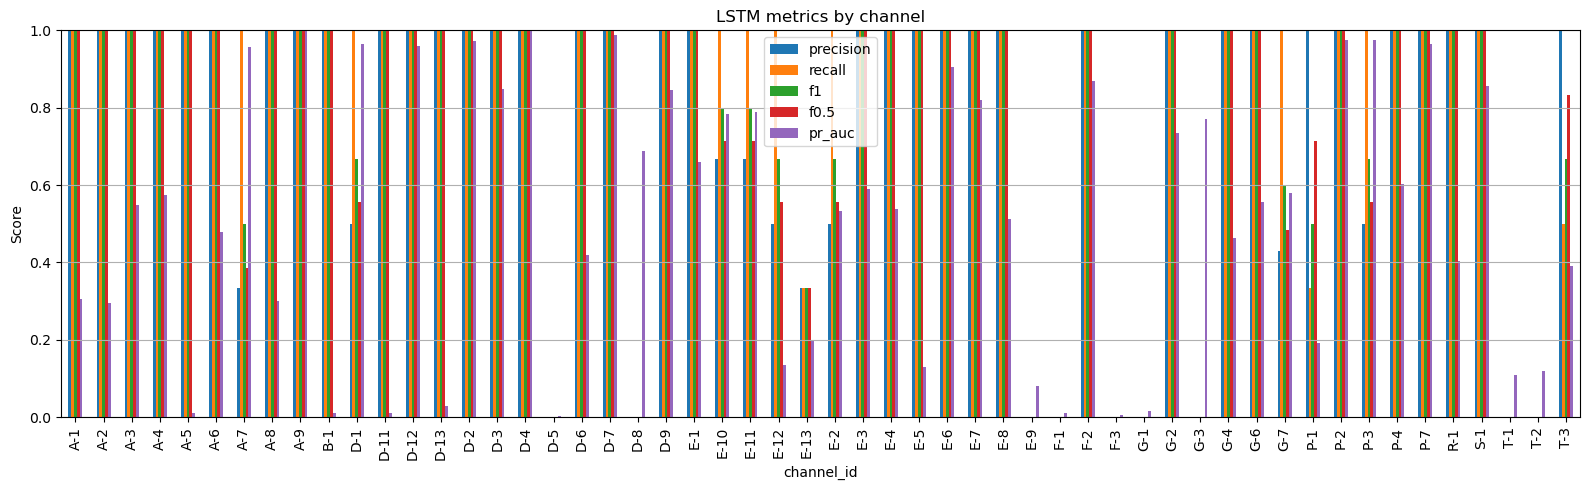

In [37]:
plot_overall_metrics(lstm_result_df,method_name='LSTM')

### Reconstruction-Based vs Forecasting-Based Anomaly Scores

The VAE and the LSTM produce anomaly scores with different meanings. In the VAE pipeline, the anomaly score is based on the reconstruction error of the current telemetry window. The model receives a multivariate window, compresses it into a latent representation, reconstructs the same window, and assigns a high score when the reconstruction is poor.

Therefore, the VAE answers the question: *is this telemetry window compatible with the normal windows seen during training?*

The LSTM pipeline follows a different logic. It receives the past telemetry window and predicts the future values of the main signal. The anomaly score is then computed from the forecasting error between the predicted and observed future signal.

Therefore, the LSTM answers the question: *is the future behavior of the main signal consistent with its past temporal and command context?*

This distinction makes the comparison methodologically useful. The VAE tests whether anomalies can be detected by reconstructing the observed multivariate window, while the LSTM tests whether anomalies are better captured as unexpected future deviations. Since the SMAP labels refer to anomalous temporal behavior of the main telemetry signal, comparing these two approaches helps assess whether the task is more naturally framed as reconstruction-based or forecasting-based anomaly detection.

### LSTM vs VAE Results Comparison

The comparison between the LSTM and the VAE confirms the methodological difference between forecasting-based and reconstruction-based anomaly detection.

The LSTM obtains higher recall and F1-score:

$$
\text{LSTM recall} = 0.735, \qquad \text{VAE recall} = 0.568
$$

$$
\text{LSTM F1} = 0.625, \qquad \text{VAE F1} = 0.565
$$

This means that the LSTM is more effective at detecting labeled anomalous sequences. Since the LSTM anomaly score is based on forecasting error, these results suggest that many SMAP anomalies are better captured as deviations from the expected future behavior of the main telemetry signal, rather than as windows that are difficult to reconstruct.

The VAE obtains slightly higher precision:

$$
\text{VAE precision} = 0.593, \qquad \text{LSTM precision} = 0.583
$$

However, this improvement is small and comes with a clear drop in recall. The VAE is more conservative, as also shown by its lower predicted anomaly ratio:

$$
\text{VAE anomaly ratio} = 3.99\%, \qquad \text{LSTM anomaly ratio} = 5.63\%
$$

Therefore, the VAE raises fewer alarms, but it also misses more true anomalous sequences. This behavior is coherent with a reconstruction-based detector: if an anomalous window is still compatible with the normal reconstruction manifold, the VAE may not assign it a sufficiently high anomaly score.

The PR-AUC also favors the LSTM:

$$
\text{LSTM PR-AUC} = 0.489, \qquad \text{VAE PR-AUC} = 0.290
$$

This indicates that the LSTM forecasting errors provide a better ranking of anomalous versus nominal points than the VAE reconstruction scores. In other words, the continuous anomaly scores produced by the LSTM are more informative before the final dynamic thresholding and post-processing stage.

Overall, the VAE provides a useful reconstruction-based baseline, but the LSTM gives better detection performance on this task. The results support the idea that SMAP anomaly detection is more naturally framed as a forecasting problem: the relevant signal is not only whether the current telemetry window can be reconstructed, but whether the future behavior of the main telemetry variable is consistent with its previous temporal and command context.

## LSTM-VAE

The LSTM-VAE is introduced as a reconstruction-based temporal anomaly detection model. The model receives a multivariate telemetry window and tries to reconstruct the same window, similarly to the standard VAE. However, instead of flattening the input window, the LSTM-VAE processes it as a temporal sequence.

The encoder LSTM compresses the input window into a latent distribution, parameterized by a mean vector and a log-variance vector. A latent representation is then sampled through the reparameterization trick and passed to the decoder LSTM, which reconstructs the original temporal window.

Since the model is trained on normal training data, windows following normal temporal dynamics are expected to have low reconstruction error. Conversely, anomalous windows are expected to be reconstructed less accurately and therefore produce higher anomaly scores.

The final anomaly detection pipeline remains the same as for the other reconstruction-based models: reconstruction error, EWMA smoothing, dynamic thresholding, pruning and sequence-aware evaluation.

In [97]:
class LSTMVaeDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_lstm_vae_loader(X, batch_size=64, shuffle=True):
    dataset = LSTMVaeDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [98]:
class LSTMVAE(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        latent_size=32,
        num_layers=1
    ):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)

        self.latent_to_hidden = nn.Linear(latent_size, hidden_size)

        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]

        mu = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z, seq_len):
        decoder_input = self.latent_to_hidden(z)
        decoder_input = decoder_input.unsqueeze(1).repeat(1, seq_len, 1)

        decoder_output, _ = self.decoder_lstm(decoder_input)

        x_recon = self.output_layer(decoder_output)

        return x_recon

    def forward(self, x):
        seq_len = x.size(1)

        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z, seq_len)

        return x_recon, mu, logvar

In [99]:
def lstm_vae_loss_function(x_recon, x, mu, logvar, beta=1e-3):
    """
    LSTM-VAE loss = reconstruction loss + beta * KL divergence.
    """

    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

In [103]:
def train_lstm_vae_channel(
        X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_lstm_vae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_lstm_vae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[2]

    model = LSTMVAE(
        input_size=input_size,
        hidden_size=hidden_size,
        latent_size=latent_size,
        num_layers=num_layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon, mu, logvar = model(X_batch)

            loss, recon_loss, kl_loss = lstm_vae_loss_function(
                x_recon=X_recon,
                x=X_batch,
                mu=mu,
                logvar=logvar,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_recon += recon_loss.item() * X_batch.size(0)
            train_kl += kl_loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_recon /= len(train_loader.dataset)
        train_kl /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()

            val_loss = 0.0
            val_recon = 0.0
            val_kl = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon, mu, logvar = model(X_batch)

                    loss, recon_loss, kl_loss = lstm_vae_loss_function(
                        x_recon=X_recon,
                        x=X_batch,
                        mu=mu,
                        logvar=logvar,
                        beta=beta
                    )

                    val_loss += loss.item() * X_batch.size(0)
                    val_recon += recon_loss.item() * X_batch.size(0)
                    val_kl += kl_loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)
            val_recon /= len(val_loader.dataset)
            val_kl /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": val_loss,
                "val_recon_loss": val_recon,
                "val_kl_loss": val_kl
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": np.nan,
                "val_recon_loss": np.nan,
                "val_kl_loss": np.nan
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f}"
            )

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [104]:
def compute_lstm_vae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.
    """

    loader = make_lstm_vae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)

            X_recon, mu, logvar = model(X_batch)

            # MSE per window over time and features
            mse_errors = torch.mean(
                (X_batch - X_recon) ** 2,
                dim=(1, 2)
            )

            all_scores.append(mse_errors.cpu().numpy())

    return np.concatenate(all_scores)

In [105]:
lstm_vae_models = {}
lstm_vae_histories = {}
lstm_vae_scores = {}
lstm_vae_smoothed_scores = {}
lstm_vae_predictions_binary = {}
lstm_vae_thresholds = {}
lstm_vae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM-VAE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_vae_channel(
        X_train=X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_lstm_vae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_vae_models[ch] = model.to("cpu")
    lstm_vae_histories[ch] = history
    lstm_vae_scores[ch] = scores
    lstm_vae_smoothed_scores[ch] = smoothed_scores
    lstm_vae_predictions_binary[ch] = y_pred
    lstm_vae_thresholds[ch] = thresholds
    lstm_vae_metrics[ch] = metrics

    display(metrics)

Training LSTM-VAE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.045903 | val loss: 0.021540
Epoch 02 | train loss: 0.022127 | val loss: 0.018866
Epoch 03 | train loss: 0.020857 | val loss: 0.018343
Epoch 04 | train loss: 0.020527 | val loss: 0.018137
Epoch 05 | train loss: 0.020394 | val loss: 0.018041
Epoch 06 | train loss: 0.020326 | val loss: 0.018005
Epoch 07 | train loss: 0.020285 | val loss: 0.018002
Epoch 08 | train loss: 0.020254 | val loss: 0.017936
Epoch 09 | train loss: 0.020231 | val loss: 0.017951
Epoch 10 | train loss: 0.020209 | val loss: 0.017893
Epoch 11 | train loss: 0.020189 | val loss: 0.017881
Epoch 12 | train loss: 0.020176 | val loss: 0.017849
Epoch 13 | train loss: 0.020163 | val loss: 0.017881
Epoch 14 | train loss: 0.020146 | val loss: 0.017831
Epoch 15 | train loss: 0.020137 | val loss: 0.017828
Early stopping at epoch 15


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.026313,0.0


Training LSTM-VAE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.036796 | val loss: 0.034344
Epoch 02 | train loss: 0.033268 | val loss: 0.033904
Epoch 03 | train loss: 0.033065 | val loss: 0.033839
Epoch 04 | train loss: 0.033027 | val loss: 0.033808
Epoch 05 | train loss: 0.033008 | val loss: 0.033801
Epoch 06 | train loss: 0.032998 | val loss: 0.033790
Epoch 07 | train loss: 0.032992 | val loss: 0.033782
Epoch 08 | train loss: 0.032985 | val loss: 0.033782
Epoch 09 | train loss: 0.032981 | val loss: 0.033774
Epoch 10 | train loss: 0.032980 | val loss: 0.033772
Epoch 11 | train loss: 0.032978 | val loss: 0.033774
Epoch 12 | train loss: 0.032976 | val loss: 0.033769
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.011581,0.0


Training LSTM-VAE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.032644 | val loss: 0.029768
Epoch 02 | train loss: 0.028877 | val loss: 0.029368
Epoch 03 | train loss: 0.028698 | val loss: 0.029269
Epoch 04 | train loss: 0.028651 | val loss: 0.029259
Epoch 05 | train loss: 0.028639 | val loss: 0.029242
Epoch 06 | train loss: 0.028631 | val loss: 0.029196
Epoch 07 | train loss: 0.028626 | val loss: 0.029224
Epoch 08 | train loss: 0.028615 | val loss: 0.029258
Epoch 09 | train loss: 0.028616 | val loss: 0.029232
Epoch 10 | train loss: 0.028609 | val loss: 0.029251
Epoch 11 | train loss: 0.028609 | val loss: 0.029225
Epoch 12 | train loss: 0.028608 | val loss: 0.029223
Early stopping at epoch 12


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.351378,0.0


Training LSTM-VAE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.026819 | val loss: 0.016591
Epoch 02 | train loss: 0.019273 | val loss: 0.015803
Epoch 03 | train loss: 0.018918 | val loss: 0.015668
Epoch 04 | train loss: 0.018833 | val loss: 0.015591
Epoch 05 | train loss: 0.018797 | val loss: 0.015591
Epoch 06 | train loss: 0.018775 | val loss: 0.015565
Epoch 07 | train loss: 0.018767 | val loss: 0.015579
Epoch 08 | train loss: 0.018756 | val loss: 0.015555
Epoch 09 | train loss: 0.018754 | val loss: 0.015569
Epoch 10 | train loss: 0.018746 | val loss: 0.015552
Epoch 11 | train loss: 0.018736 | val loss: 0.015552
Epoch 12 | train loss: 0.018732 | val loss: 0.015508
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.487385,0.0


Training LSTM-VAE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.018366 | val loss: 0.002357
Epoch 02 | train loss: 0.003380 | val loss: 0.000644
Epoch 03 | train loss: 0.002632 | val loss: 0.000362
Epoch 04 | train loss: 0.002462 | val loss: 0.000260
Epoch 05 | train loss: 0.002388 | val loss: 0.000214
Epoch 06 | train loss: 0.002355 | val loss: 0.000187
Epoch 07 | train loss: 0.002333 | val loss: 0.000188
Epoch 08 | train loss: 0.002317 | val loss: 0.000170
Epoch 09 | train loss: 0.002303 | val loss: 0.000150
Epoch 10 | train loss: 0.002291 | val loss: 0.000128
Epoch 11 | train loss: 0.002283 | val loss: 0.000129
Epoch 12 | train loss: 0.002272 | val loss: 0.000138
Epoch 13 | train loss: 0.002267 | val loss: 0.000104
Epoch 14 | train loss: 0.002259 | val loss: 0.000101
Early stopping at epoch 14


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.045711,0.0


In [106]:
lstm_vae_results_df, lstm_vae_summary_df = generate_results_view(lstm_vae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.0,0.0,0.0,0.0,0.026313,0.000000
1,A-2,0,0,1,0.0,0.0,0.0,0.0,0.011581,0.000000
2,A-3,0,0,1,0.0,0.0,0.0,0.0,0.024765,0.000000
3,A-4,0,0,1,0.0,0.0,0.0,0.0,0.011200,0.000000
4,A-5,0,1,1,0.0,0.0,0.0,0.0,0.010754,0.059791
5,A-6,0,0,1,0.0,0.0,0.0,0.0,0.037578,0.000000
6,A-7,0,0,1,0.0,0.0,0.0,0.0,0.159958,0.000000
7,A-8,0,0,1,0.0,0.0,0.0,0.0,0.582143,0.000000
8,A-9,0,0,1,0.0,0.0,0.0,0.0,0.970649,0.000000
9,B-1,0,1,1,0.0,0.0,0.0,0.0,0.008059,0.043565


TP                                6.000000
FP                                3.000000
FN                               62.000000
precision                         0.666667
recall                            0.088235
f1                                0.155844
f0.5                              0.288462
pr_auc_macro                      0.324683
predicted_anomaly_ratio_macro     0.006212
dtype: float64

In [107]:
save_results(lstm_vae_results_df,lstm_vae_summary_df,method_name="LSTM_VAE")

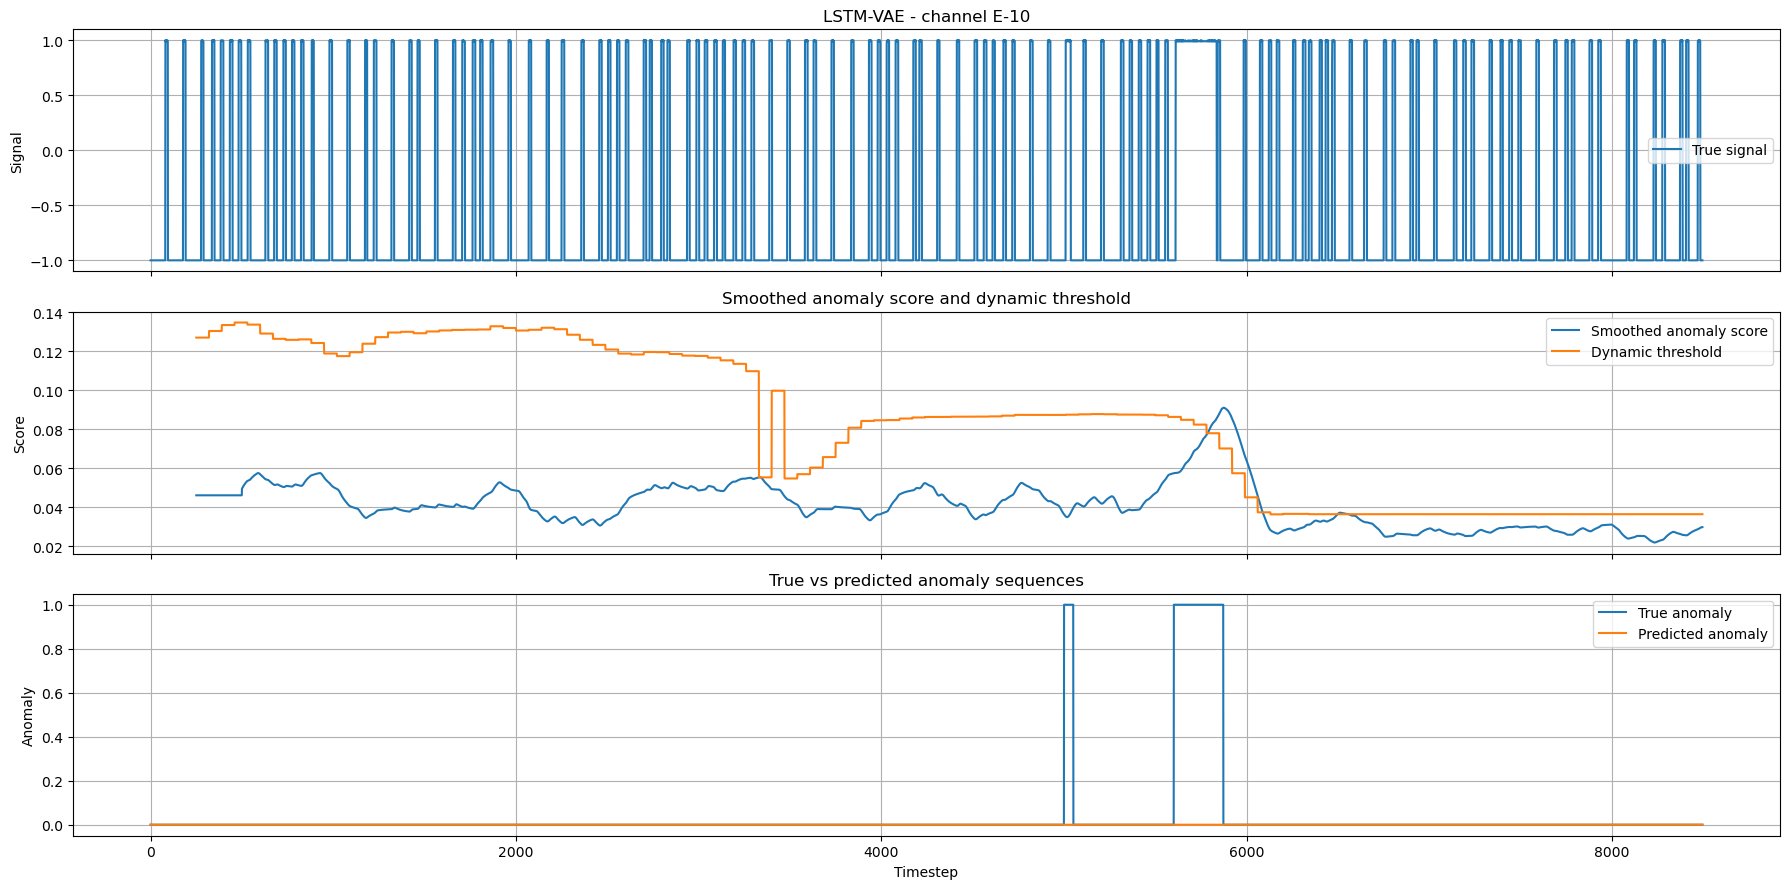

In [108]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=lstm_vae_smoothed_scores,
    thresholds=lstm_vae_thresholds,
    predictions_binary=lstm_vae_predictions_binary,
    model_name="LSTM-VAE"
)

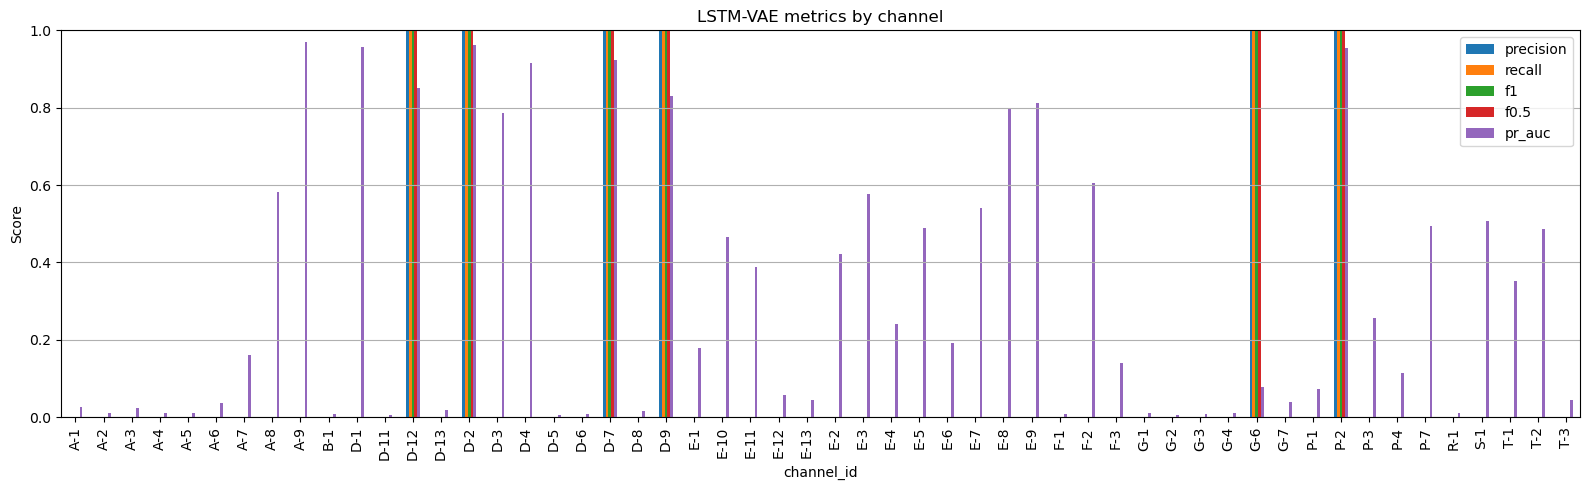

In [109]:
plot_overall_metrics(
    lstm_vae_results_df,
    method_name="LSTM-VAE"
)

### Discussion: effect of windowing, training length and Random Forest performance

A relevant aspect of this experimental setup is the relationship between the length of the training sequences and the window size used to construct the supervised learning samples. The models are trained on sliding windows of length 250 with stride one. This choice produces a large number of training windows, but these windows are not independent. Two consecutive windows share almost all their observations, since only one timestep changes between them. Therefore, the nominal number of generated training samples can be misleading: the effective amount of independent information available to the model is much smaller.

This issue becomes particularly important for channels with short training sequences. For example, if a channel contains only about 600 training timesteps, a window size of 250 produces roughly 351 windows. However, these windows are highly overlapping and mostly describe the same local dynamics. As a consequence, the model may see many slightly shifted versions of the same pattern rather than genuinely diverse examples of normal behaviour. This does not represent data leakage, because the samples are still extracted only from the training set, but it limits the effective diversity of the training data.

The problem is amplified by the fact that, in this dataset, the test sequences can be much longer than the corresponding training sequences. The model is therefore asked to generalize from a relatively short normal training segment to a longer test sequence, which may contain normal operating regimes not observed during training. In this situation, large anomaly scores may arise not only because of true anomalies, but also because the model encounters normal behaviours that were under-represented or absent in the training data. This is an intrinsic limitation of the available train-test split and must be considered when interpreting the final results.

This also helps explain why the Random Forest Regressor can perform surprisingly well, even though it flattens the temporal windows. Flattening removes the explicit sequential structure of the input, but it does not remove the local temporal context. Each lagged value in the window remains available as a separate input feature. Therefore, the model can still exploit information such as recent values, local switching patterns, correlations between variables and specific combinations of lagged telemetry states.

In other words, after flattening, the problem is transformed into a nonlinear tabular regression task over lagged features. Random Forests are strong models in this setting because they can capture nonlinear feature interactions without requiring gradient-based optimization. This can be advantageous when the training data are limited, redundant or noisy. The model does not need to learn a full recurrent representation of the sequence; it can instead learn local decision rules based on the observed lagged values. This is particularly relevant for channels such as E-10, where the signal shows a highly discrete switching behaviour. In this case, a large part of the useful information may already be encoded in the local window structure. A Random Forest can learn rules associated with these local configurations and produce relatively compact forecasting errors when the observed behaviour deviates from the learned normal patterns.

The fact that the anomalies are contextual does not necessarily imply that an LSTM must perform better. A contextual anomaly is a value that becomes anomalous because of the surrounding context, but this context can often be captured by a fixed window of lagged observations. If the relevant context is local and contained within the window, a flattened representation can still be sufficient. The Random Forest does not explicitly model temporal order as a recurrent network does, but the position of each lag inside the flattened vector is fixed, so the model can still distinguish between older and more recent values.

Conversely, an LSTM is theoretically more appropriate for sequential modelling, but this advantage is not automatic. It requires enough diverse training data, stable optimization and temporal dependencies that are genuinely useful for the task. When the training sequence is short and the sliding windows are highly redundant, the LSTM may not have enough information to learn a robust temporal representation. It can also produce noisier forecasts, especially when the signal is discrete or abruptly switching. In that case, the anomaly score may become less clean and less compatible with the downstream thresholding procedure.

Therefore, the better performance of the Random Forest should not be interpreted as evidence that temporal modelling is useless. A more appropriate interpretation is that, under this specific window-based representation, much of the useful anomaly information is already contained in local lagged patterns. The Random Forest is able to exploit these patterns effectively and its error profile interacts well with the subsequent post-processing steps. This point is important because the final detection performance is not determined only by the raw model error. The anomaly scores are further processed through EWMA smoothing, dynamic thresholding and pruning. A model that produces sharper and more localized error increases around true anomalous intervals may obtain better final sequence-level metrics, even if its raw anomaly scores are not globally superior. This is consistent with the observed behaviour of the Random Forest, which produces a relatively controlled predicted anomaly ratio and compact detections around the main anomalous regions. At the same time, the moderate PR-AUC suggests that the continuous anomaly scores do not perfectly separate normal and anomalous points across all thresholds. Hence, the final F1 score should be interpreted as the result of the complete detection pipeline, not only as a property of the forecasting model itself. The strong performance of the Random Forest is therefore meaningful, but it also highlights the importance of the windowing strategy and of the post-processing pipeline in this anomaly detection task.